## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_14"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


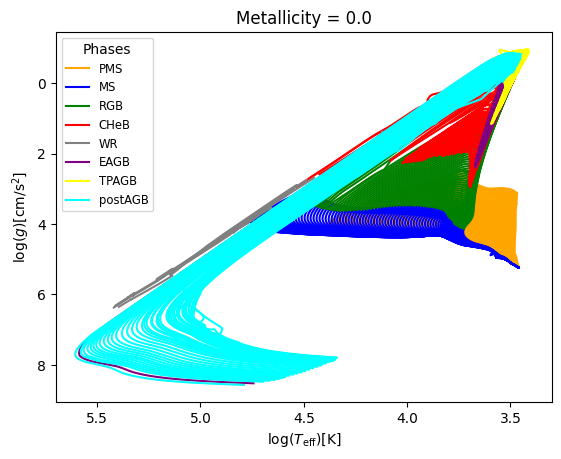

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

In [5]:
print_uniques("star_mass", iso_df)
# print_uniques_count("star_mass", iso_df)

star_mass : 1467117 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
633331,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
633332,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
633333,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
633334,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


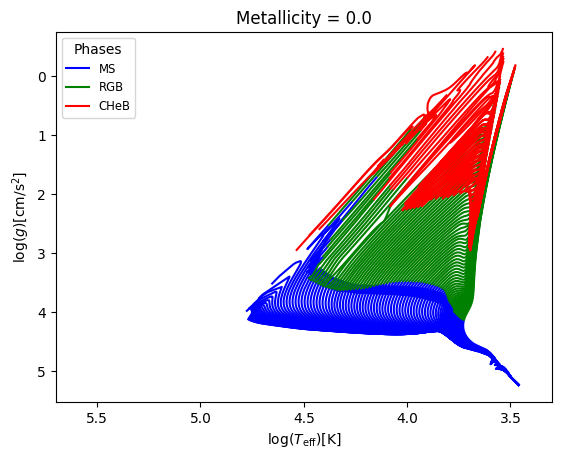

In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [7]:
print_uniques("star_mass", phase_filtered_iso_df)
# print_uniques_count("star_mass", phase_filtered_iso_df)

star_mass : 633336 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.00,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.00,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.00,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.05,4.482577,4.350883,0.0,-0.25,12.925175,0.596074
4,5.05,4.485667,4.349692,0.0,-0.25,13.105490,0.600130
...,...,...,...,...,...,...,...
522017,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
522018,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
522019,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
522020,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


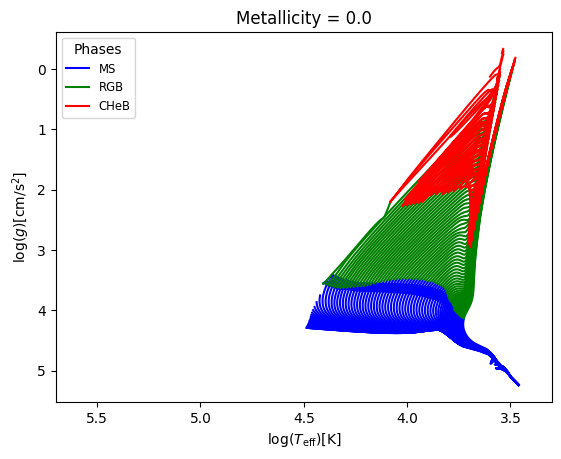

In [8]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], "star_mass" : ("<", 14)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_age_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_age_filtered.plot_Kiel([], [0.0])

In [9]:
print_all_uniques(phase_mass_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4693, Median : 8.5

log_Teff  : Range : 3.34 - 5.2138, Mean : 3.9383, Median : 3.867

log_g  : Range : -1.08 - 7.9405, Mean : 3.5574, Median : 3.9537

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 13.9995, Mean : 3.3831, Median : 2.0289

log_R  : Range : -1.86 - 3.0828, Mean : 0.6007, Median : 0.5357



In [10]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.033627748756486
Mean value in train data for the star_mass parameter: 3.3863983679375362

Range in train data for the log_R parameter : -1.859644360427887 - 3.0827540579576227
Median value in train data for the log_R parameter: 0.5359659870072869
Mean value in train data for the log_R parameter: 0.601508525333496

Testing set statistics:
Range in test data for the star_mass parameter : 0.099998335899912 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.016451195234504
Mean value in test data for the star_mass parameter: 3.3733610557459555

Range in test data for the log_R parameter : -1.861069007171269 - 3.073145982400745
Median value in test data for the log_R parameter: 0.534764829353079
Mean value in test data for the log_R parameter: 0.598323970416776

(391516, 4) (130506, 4)
(391516, 

## Model training

### Linear regression

In [11]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.697370236171527
  RMSE :  1.8158852607125213
  MAE :  1.455151466013522
  MedAE :  1.1925945561032538
  CORR :  0.8485152328791816
  MAX_ER :  7.499946999587877
  Percentiles : 
    75th percentile :  2.0730481466438953
    90th percentile :  2.8875450648253844
    95th percentile :  3.417354282585044
    99th percentile :  5.1088062726412

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.762400313993691
  RMSE :  1.5868637538295014
  MAE :  1.069708813947661
  MedAE :  0.760789110979081
  CORR :  0.9168080990761227
  MAX_ER :  6.793720968603239
  Percentiles : 
    75th percentile :  1.1547821354907795
    90th percentile :  2.278475594704764
    95th percentile :  3.9267906134376105
 

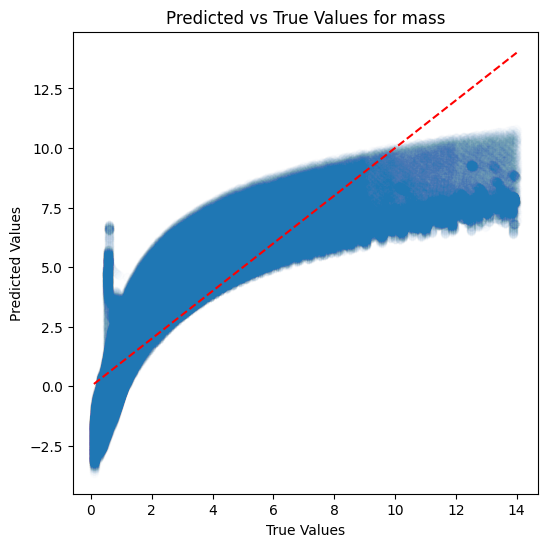

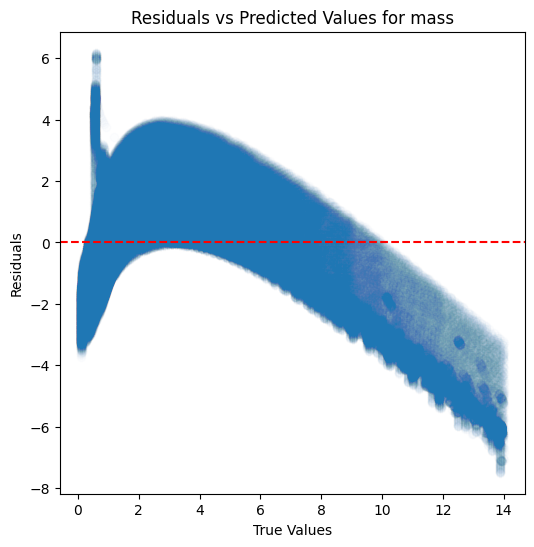

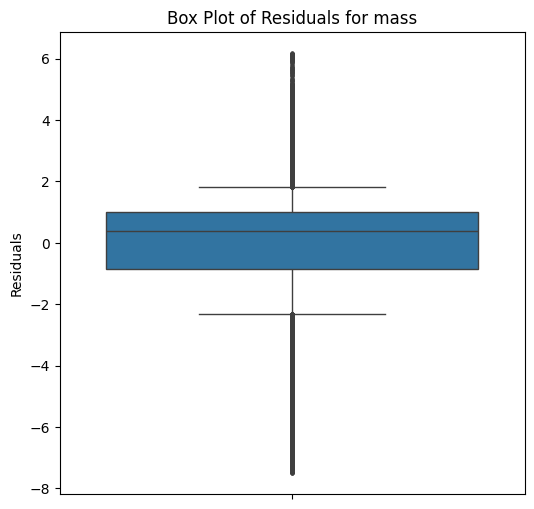

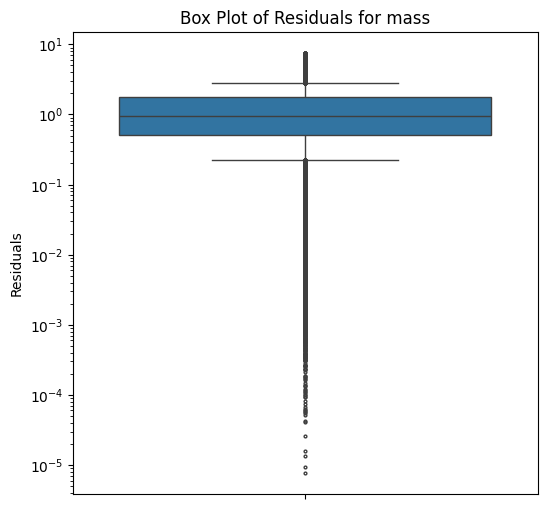

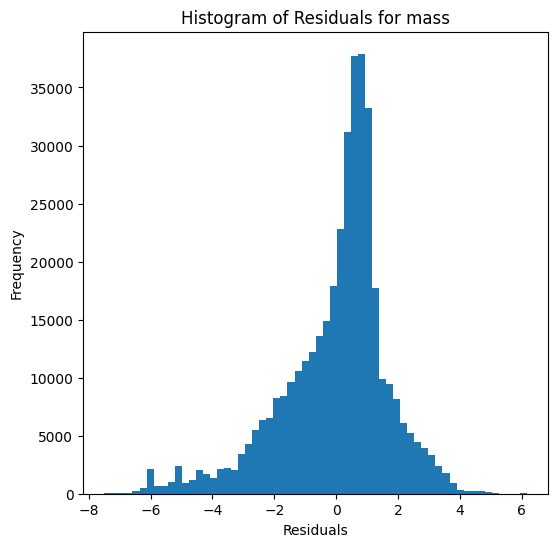

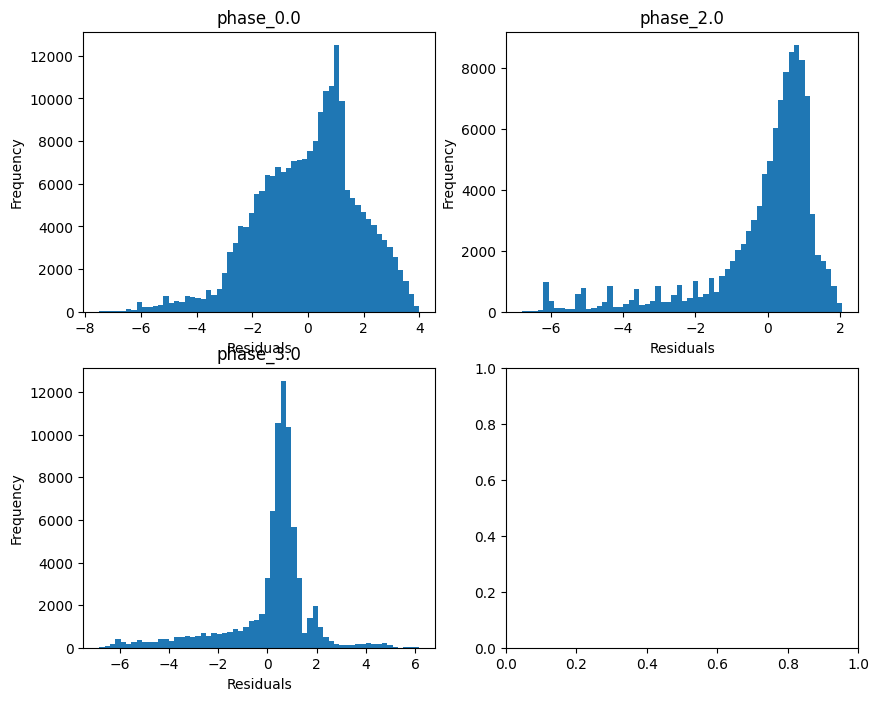

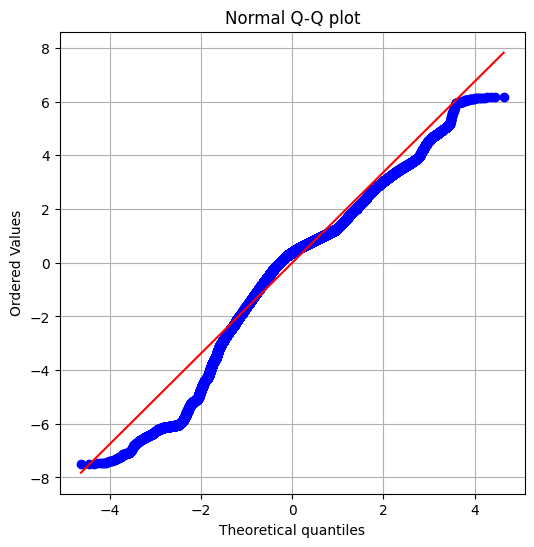

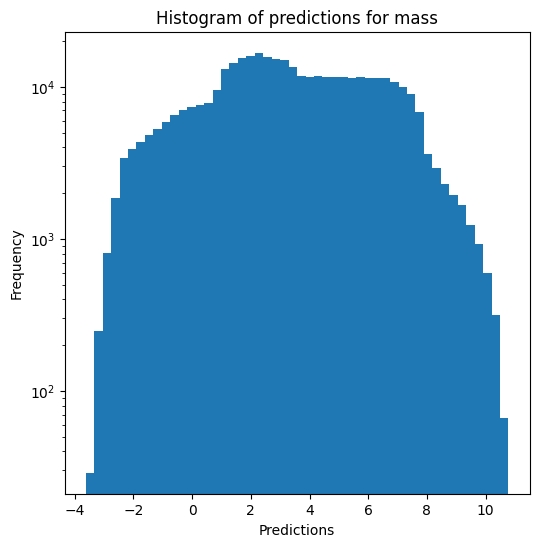

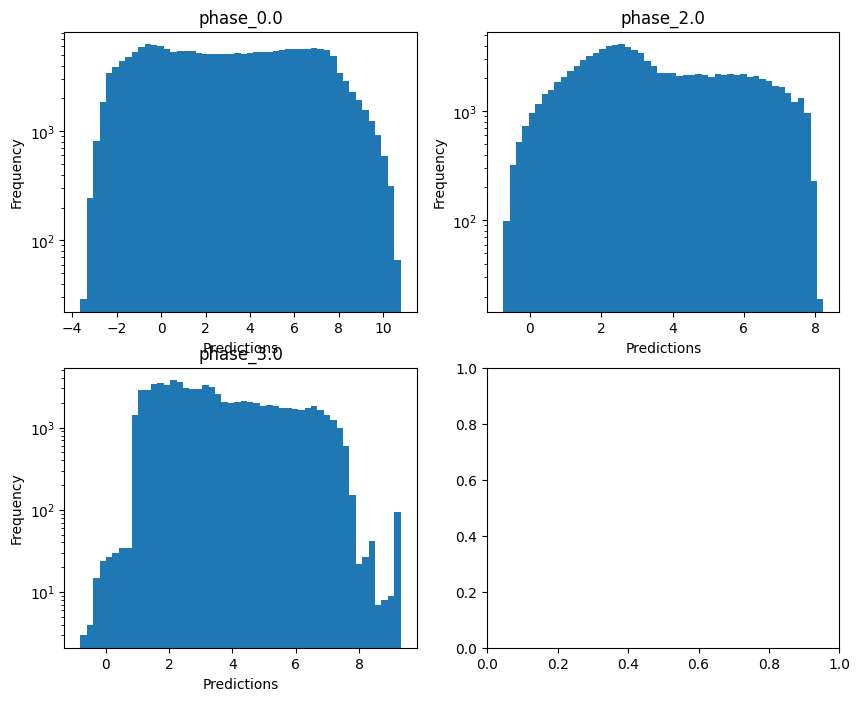

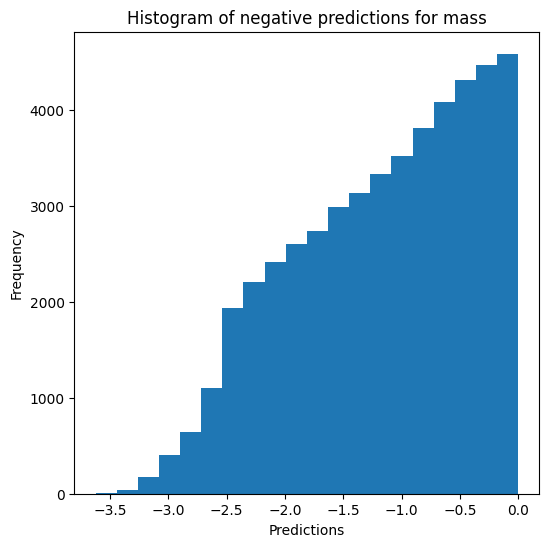


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9781333879983054
  RMSE :  0.0624000204365977
  MAE :  0.05016245389308913
  MedAE :  0.041666565581859216
  CORR :  0.9891143074974718
  MAX_ER :  0.23967427303293753
  Percentiles : 
    75th percentile :  0.07214431763616512
    90th percentile :  0.10126019335424076
    95th percentile :  0.11797085756917874
    99th percentile :  0.17180991761146136

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9821218597814573
  RMSE :  0.06428848258563957
  MAE :  0.05206851487961322
  MedAE :  0.04282191739355906
  CORR :  0.992189751850785
  MAX_ER :  0.24111969566047264
  Percentiles : 
    75th percentile :  0.07068658773949177
    90th percentile :  0.10202753339479483
    95th percentile :  0.12512935861170413
    99th percentile :  0.18057914974751169

radius results for the phase cat

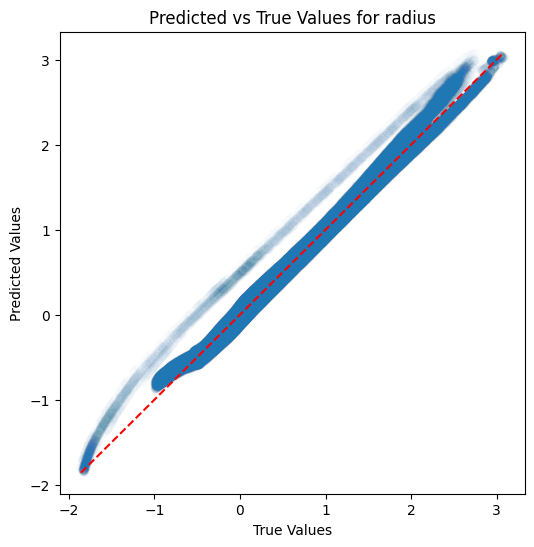

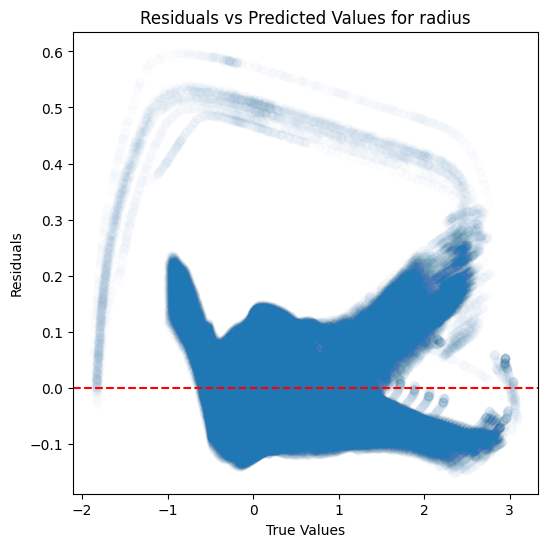

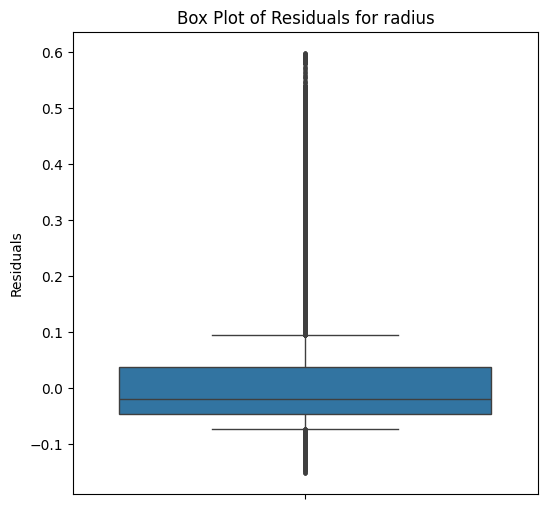

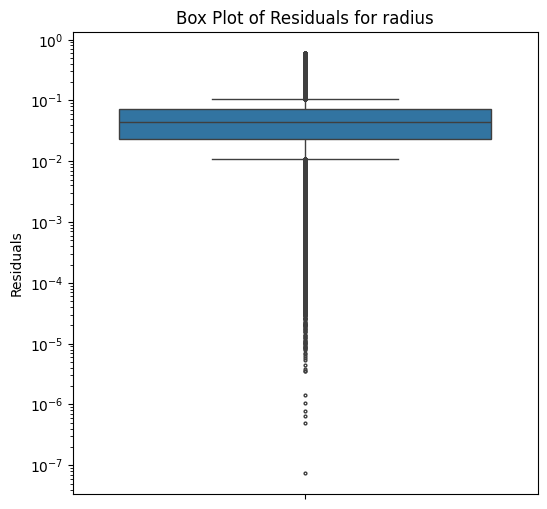

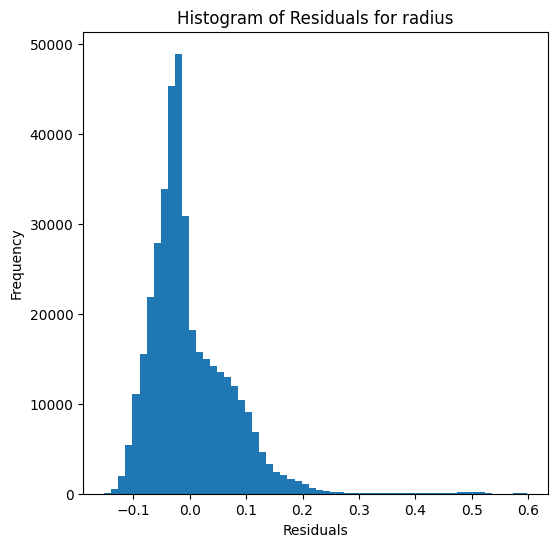

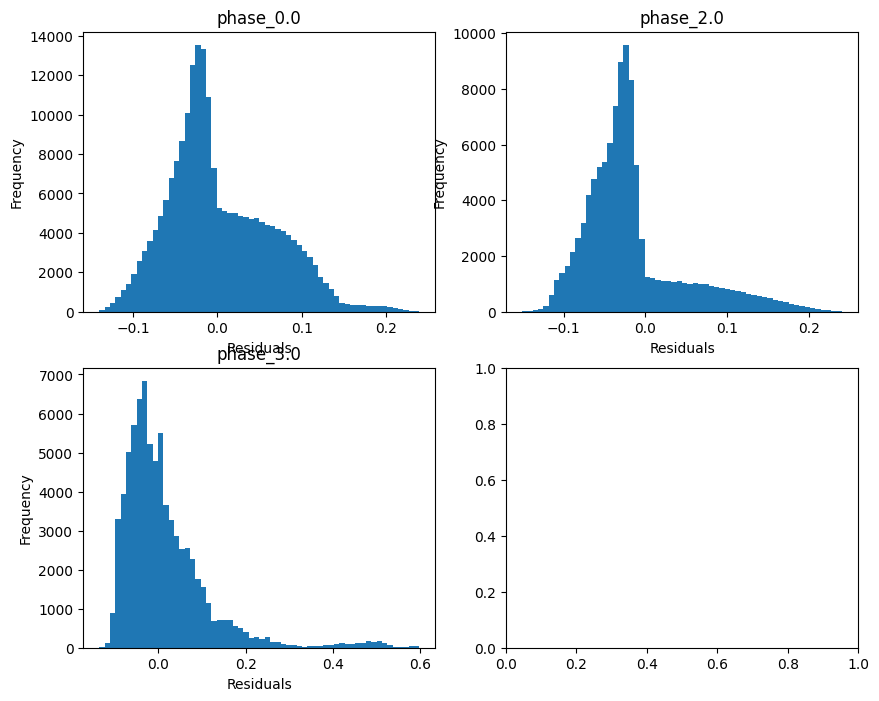

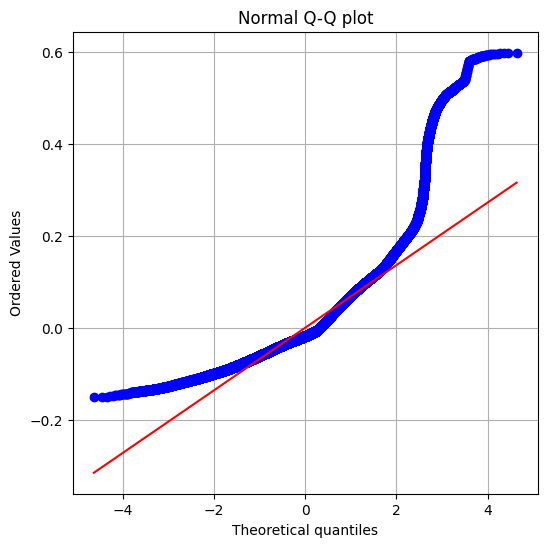

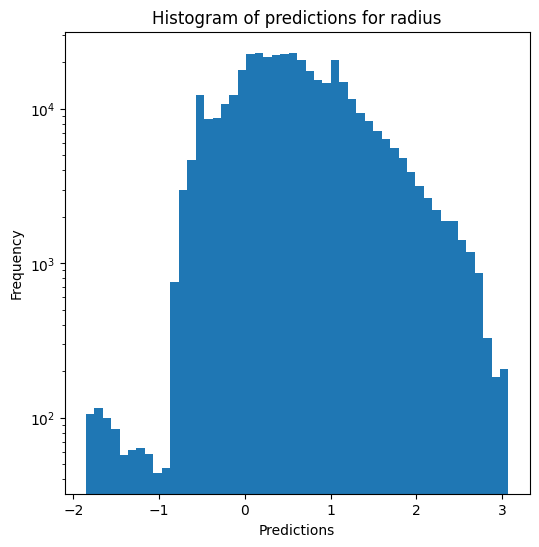

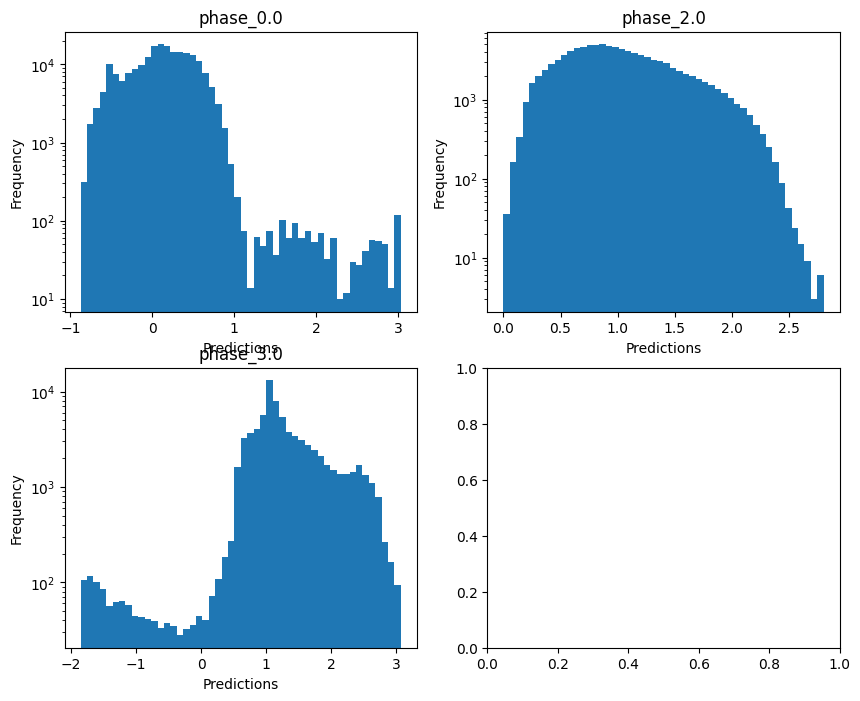

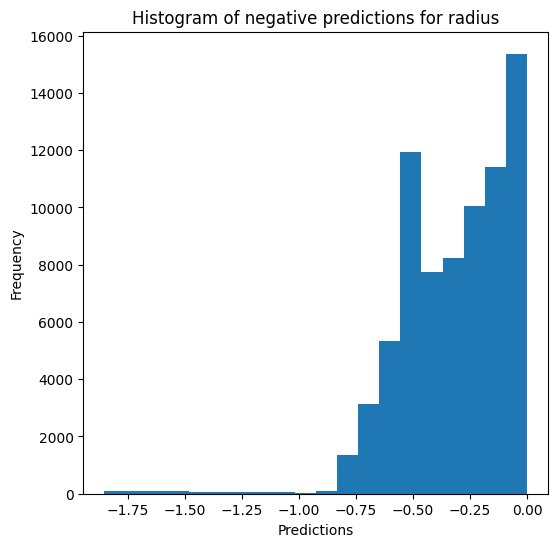

Saving predictions and results...


In [12]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### Decision tree

In [13]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997672373377944
  RMSE :  0.05036105462129625
  MAE :  0.017034433210483306
  MedAE :  0.0041133571597045115
  CORR :  0.9998836229716056
  MAX_ER :  4.851878152156933
  Percentiles : 
    75th percentile :  0.01359398588681382
    90th percentile :  0.04206581810679033
    95th percentile :  0.0743748534630555
    99th percentile :  0.19678667437587283

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999461137434603
  RMSE :  0.02385802713393943
  MAE :  0.007503332091038842
  MedAE :  0.0003194319201256235
  CORR :  0.9999731736722719
  MAX_ER :  0.6972037055216713
  Percentiles : 
    75th percentile :  0.005606295459376853
    90th percentile :  0.0232337865598

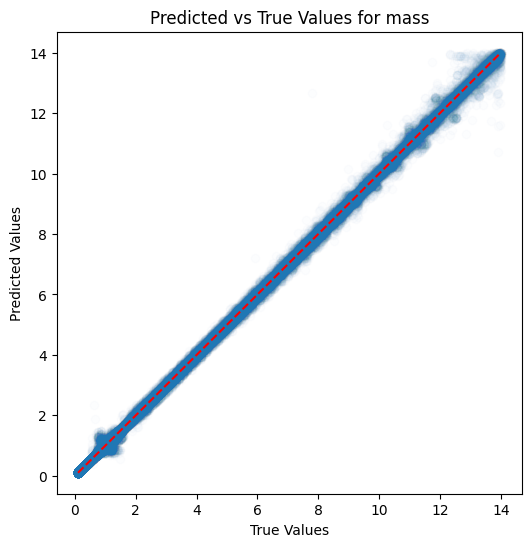

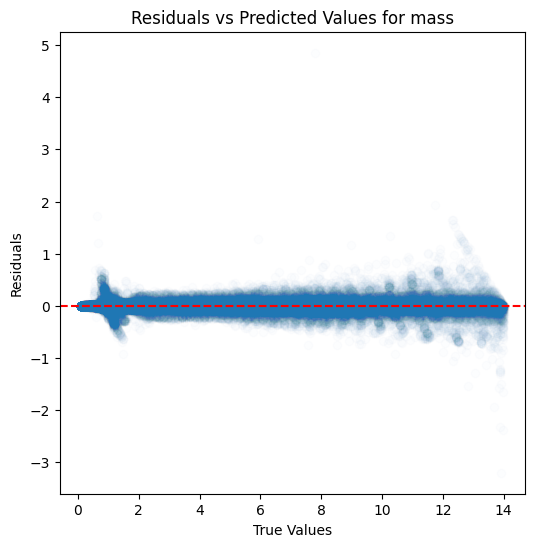

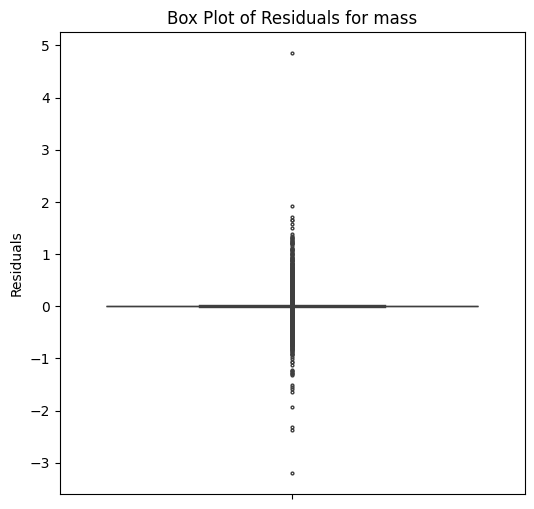

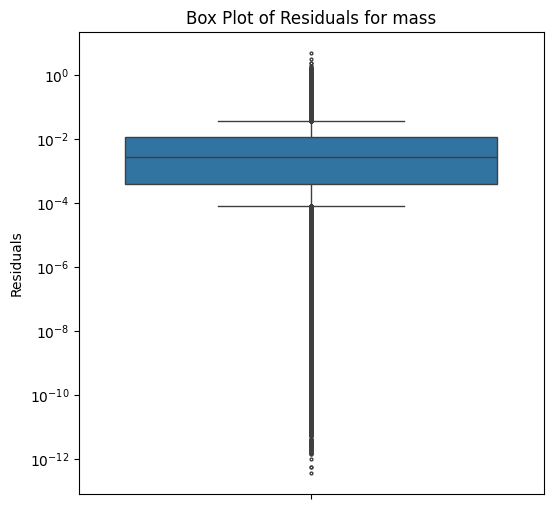

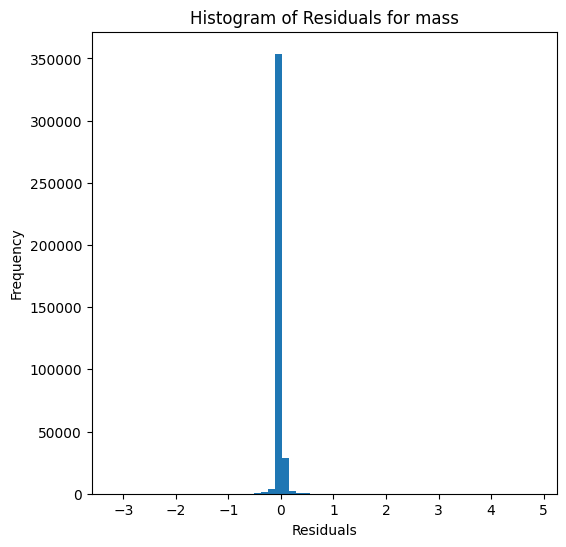

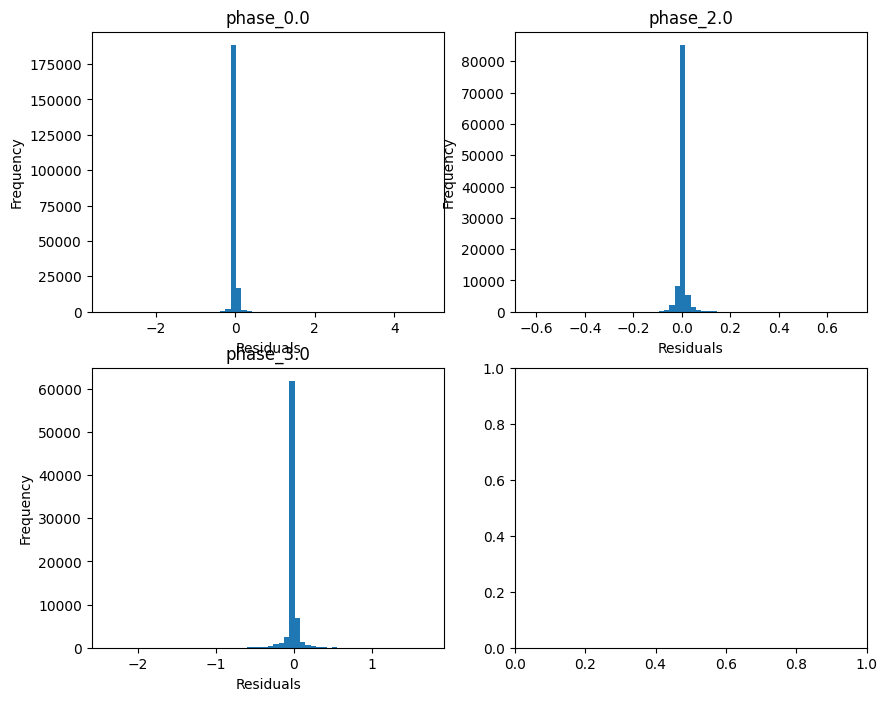

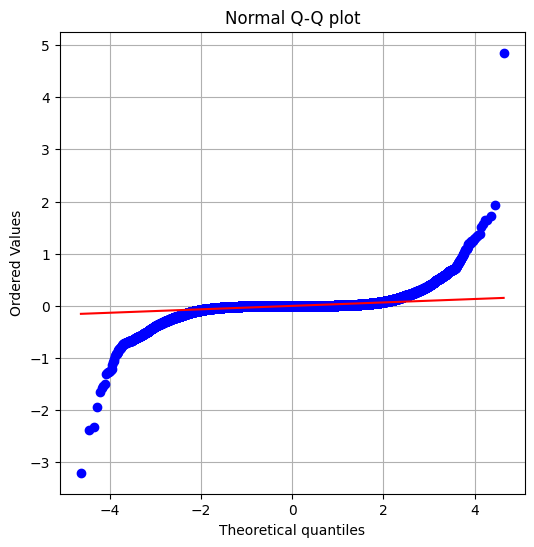

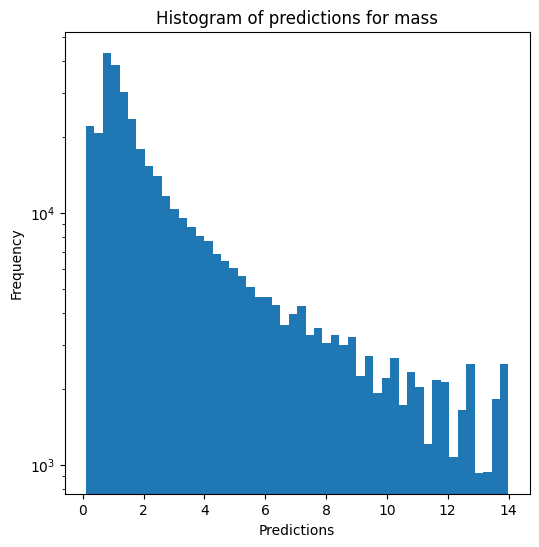

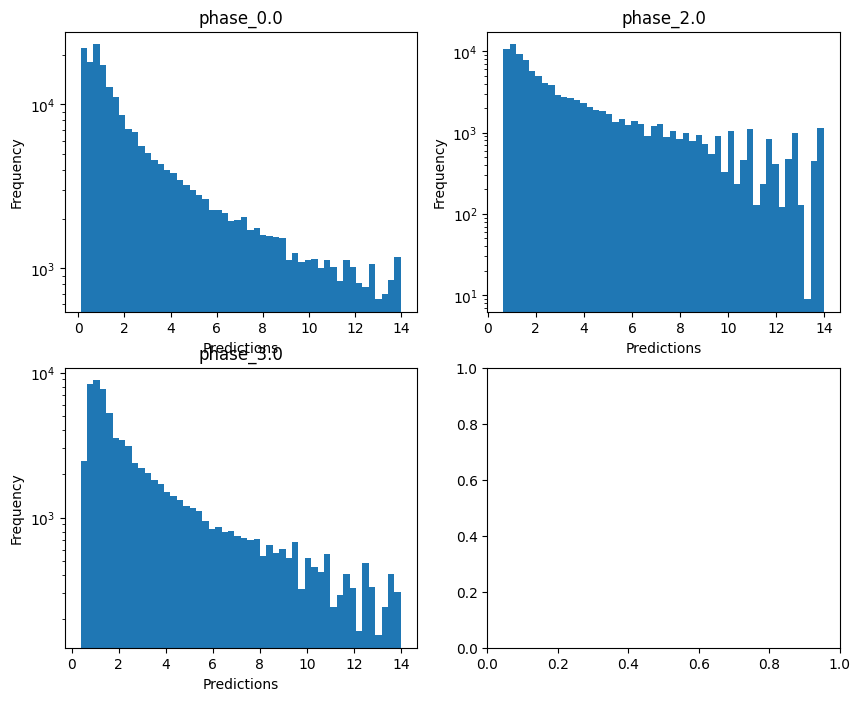


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9997928510771583
  RMSE :  0.0060687074191572345
  MAE :  0.00363079841596162
  MedAE :  0.0022819524497347254
  CORR :  0.999896420481045
  MAX_ER :  0.29687093092413097
  Percentiles : 
    75th percentile :  0.004545553222445875
    90th percentile :  0.008016617250647826
    95th percentile :  0.011322927484044717
    99th percentile :  0.023858399856353605

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9995197001584081
  RMSE :  0.010208011928967486
  MAE :  0.00733210704153488
  MedAE :  0.006049832233677943
  CORR :  0.9997619984887515
  MAX_ER :  0.1750836121341881
  Percentiles : 
    75th percentile :  0.009844727130352116
    90th percentile :  0.013819219133208938
    95th percentile :  0.017254201196971176
    99th percentile :  0.03196744443204257

radius results for t

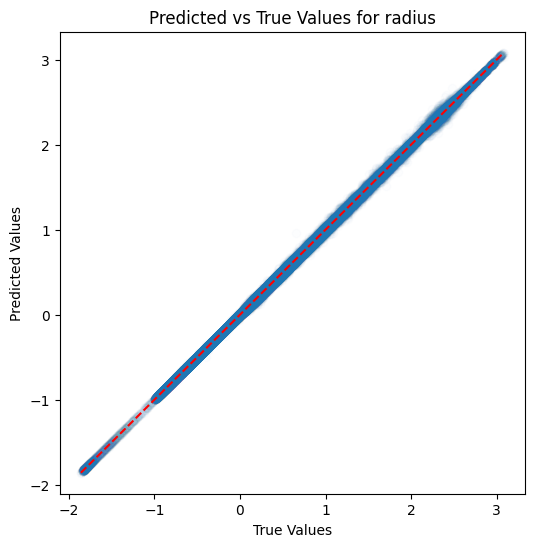

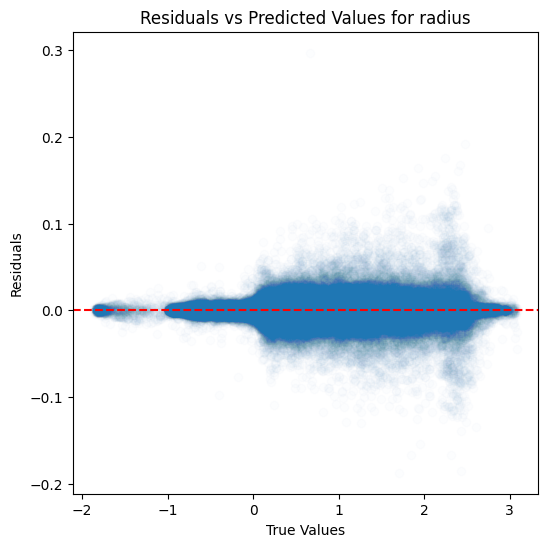

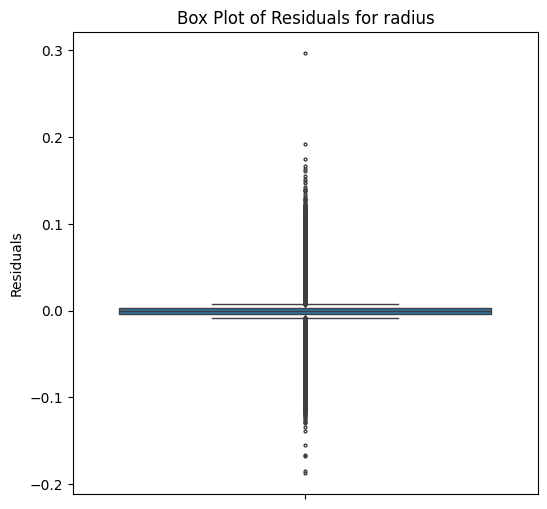

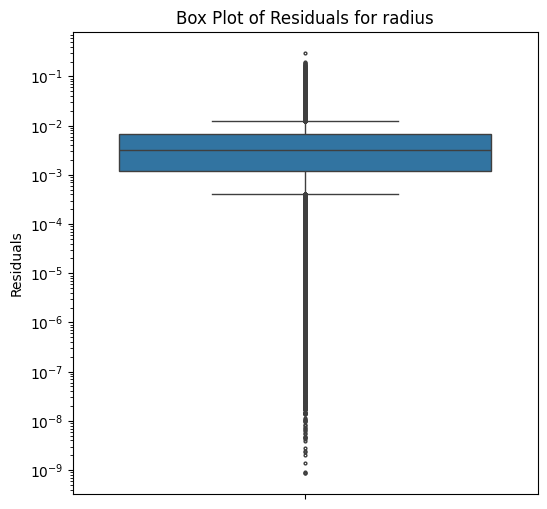

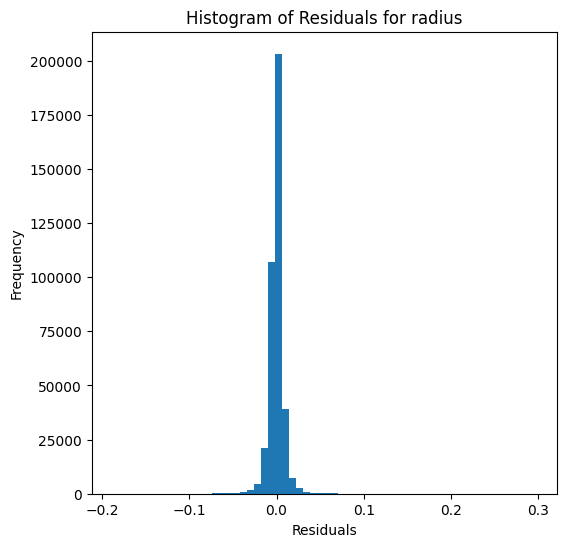

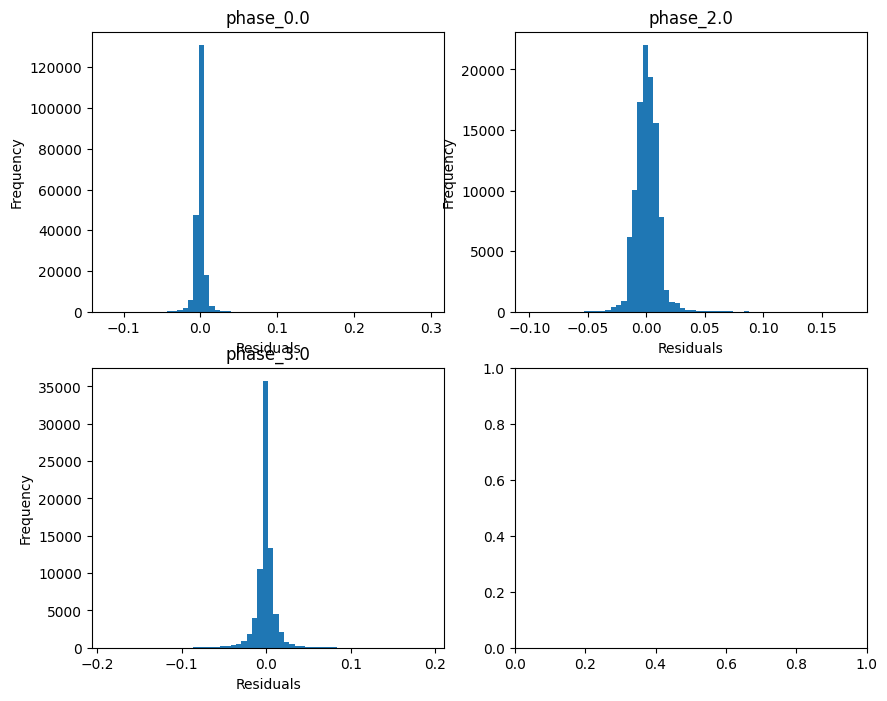

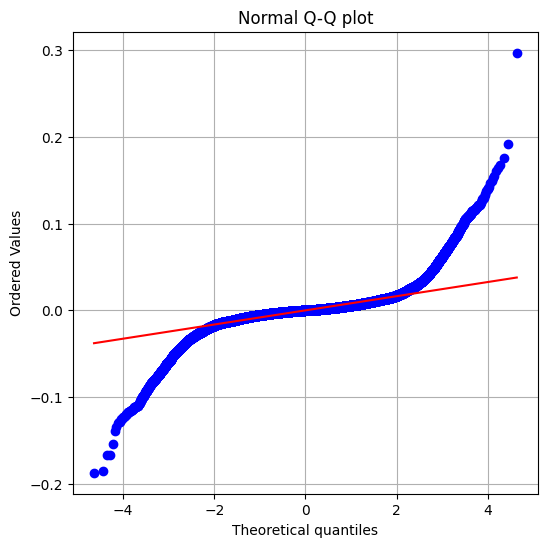

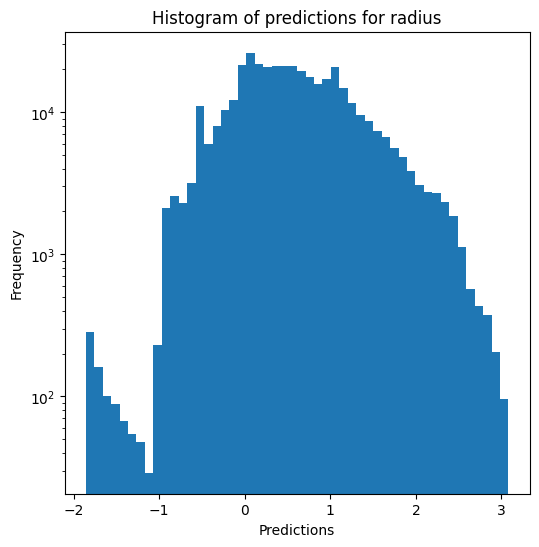

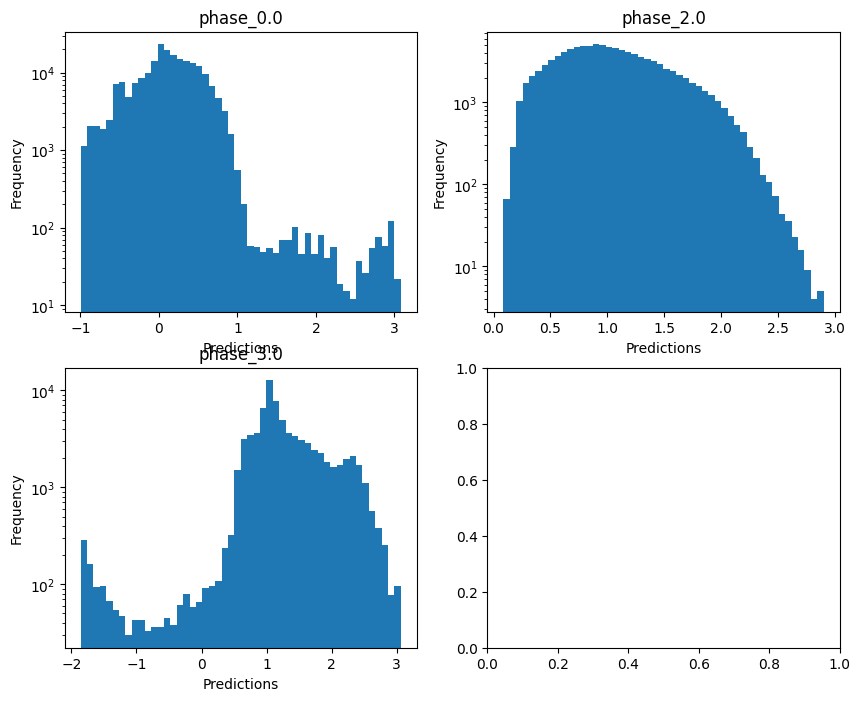

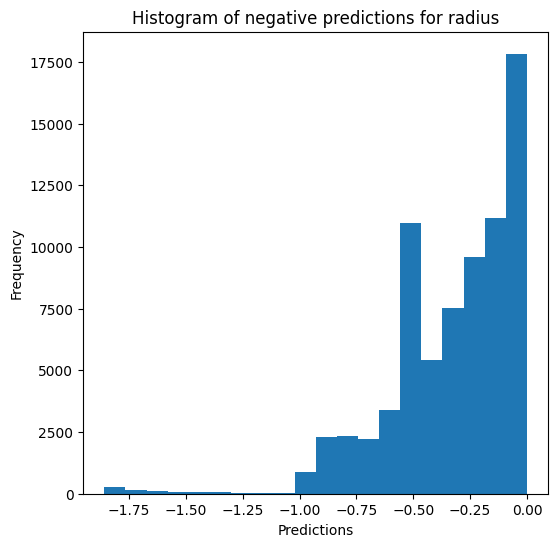

Saving predictions and results...


In [14]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### K-nearest neighbours

In [15]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9991555335313982
  RMSE :  0.09599350162514116
  MAE :  0.03094177454160305
  MedAE :  0.007145193322956933
  CORR :  0.9995872073184232
  MAX_ER :  2.556474999289428
  Percentiles : 
    75th percentile :  0.024497464716426276
    90th percentile :  0.0697239851853764
    95th percentile :  0.1238275442365792
    99th percentile :  0.3836558874172253

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997771557894501
  RMSE :  0.048526462075921734
  MAE :  0.019909272058525742
  MedAE :  0.005020707249098422
  CORR :  0.9998885716995248
  MAX_ER :  0.855295325429557
  Percentiles : 
    75th percentile :  0.016144655434631616
    90th percentile :  0.05657590064605993

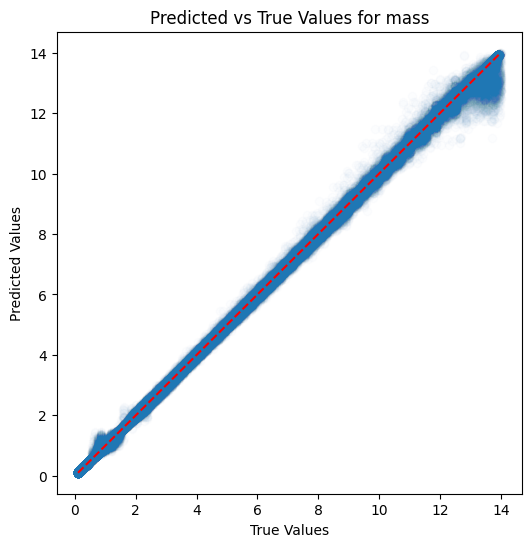

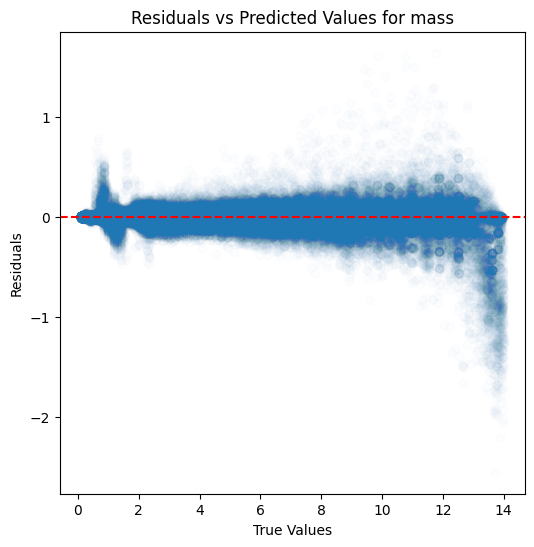

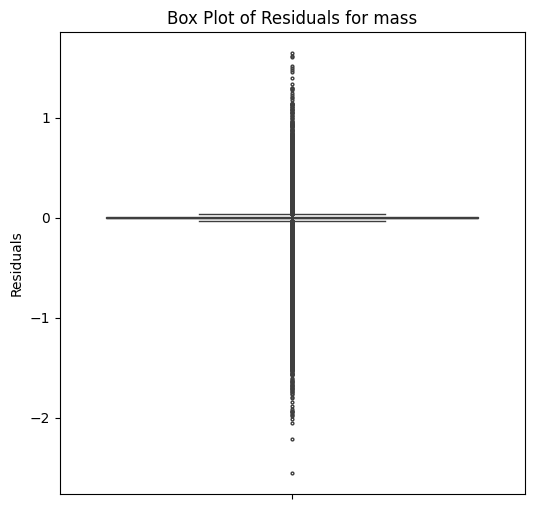

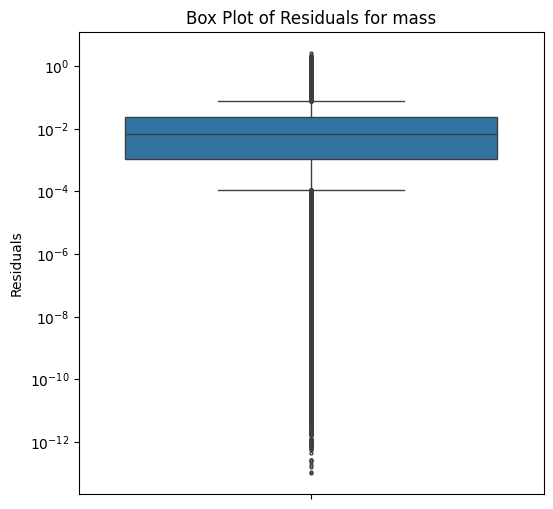

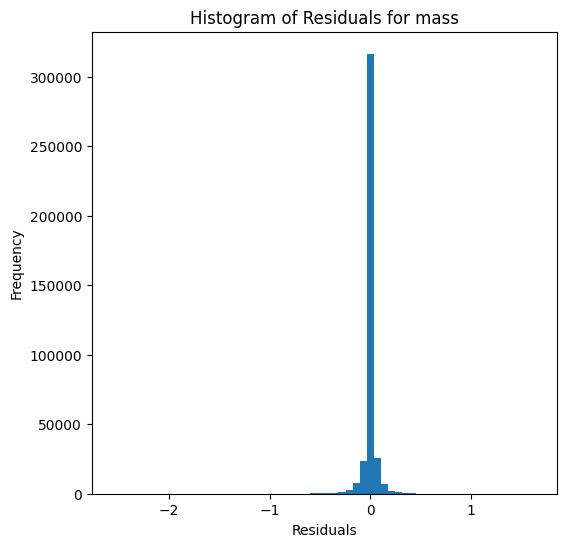

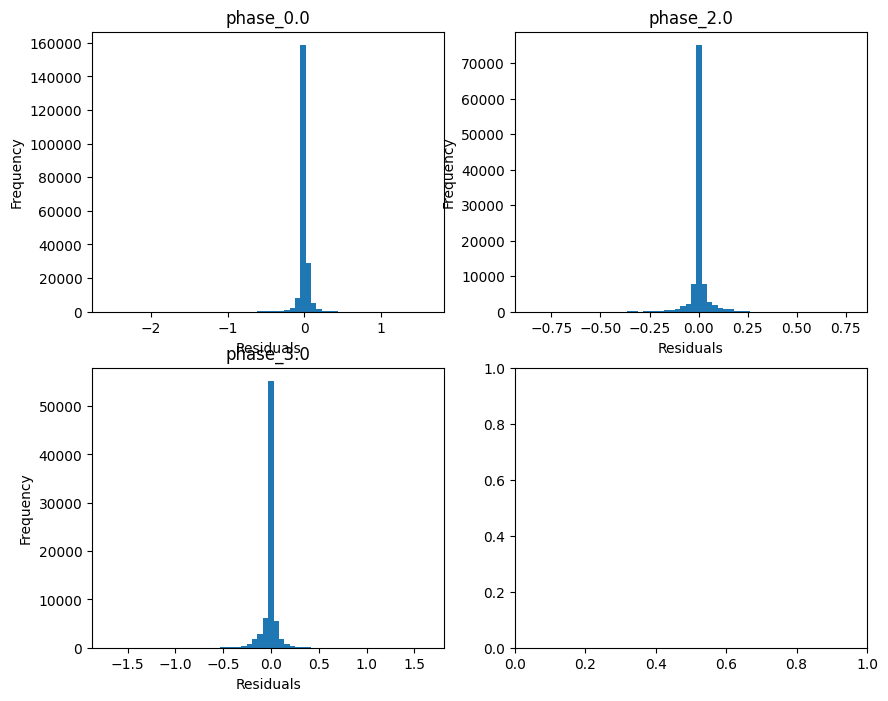

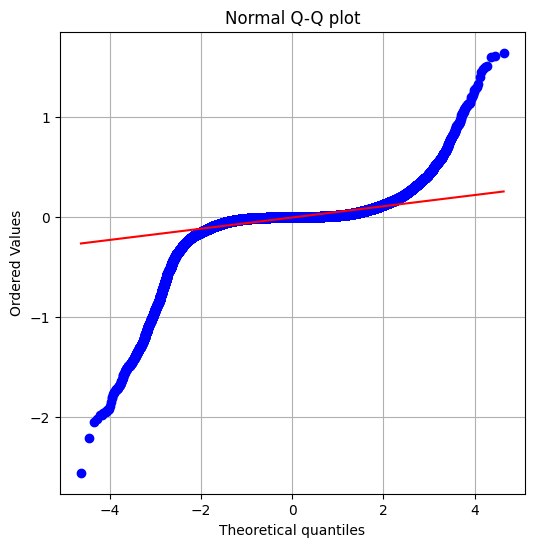

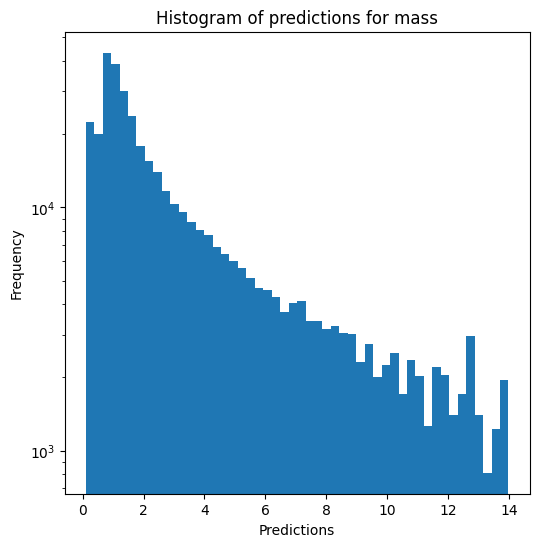

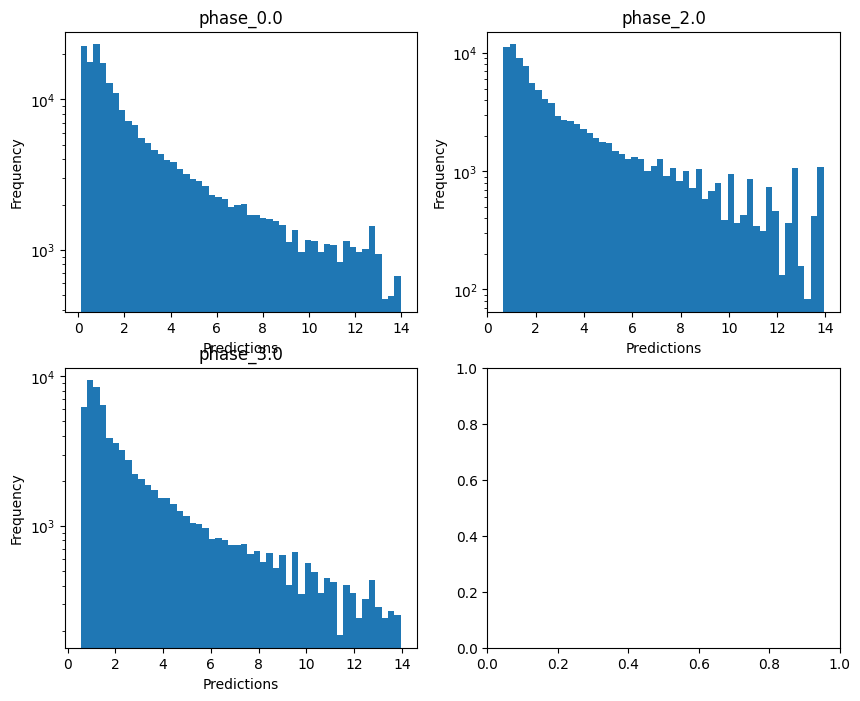


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9998244565962764
  RMSE :  0.005584677377398187
  MAE :  0.0036625411535374805
  MedAE :  0.002355228896905426
  CORR :  0.9999129950192717
  MAX_ER :  0.07454572919311686
  Percentiles : 
    75th percentile :  0.004582820985817415
    90th percentile :  0.008426422779368316
    95th percentile :  0.01173448263224657
    99th percentile :  0.02095181596244708

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9998950136532548
  RMSE :  0.004770990555919763
  MAE :  0.003645181573049165
  MedAE :  0.002854713522677965
  CORR :  0.9999475475373238
  MAX_ER :  0.050980652738506826
  Percentiles : 
    75th percentile :  0.00494833260801153
    90th percentile :  0.007896079625587497
    95th percentile :  0.009775197134488234
    99th percentile :  0.013788219245920785

radius results for

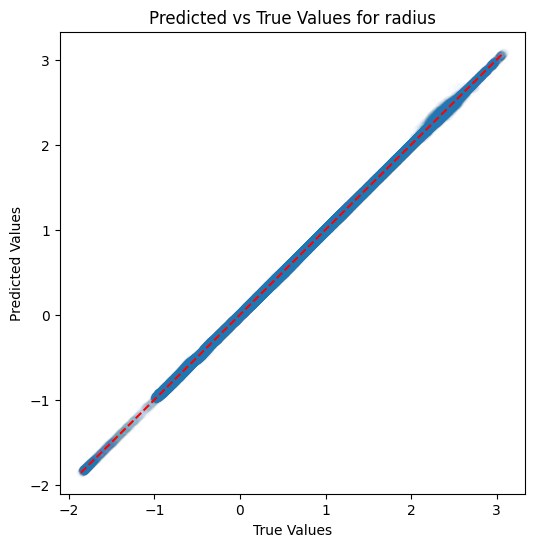

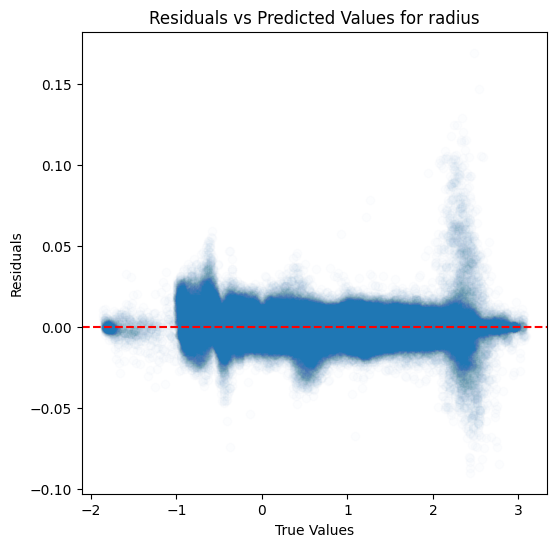

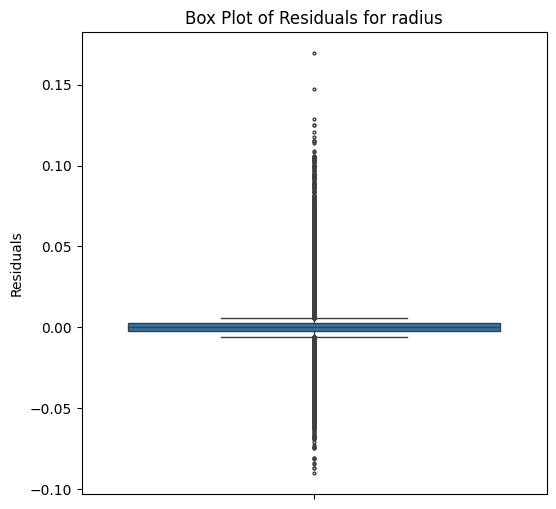

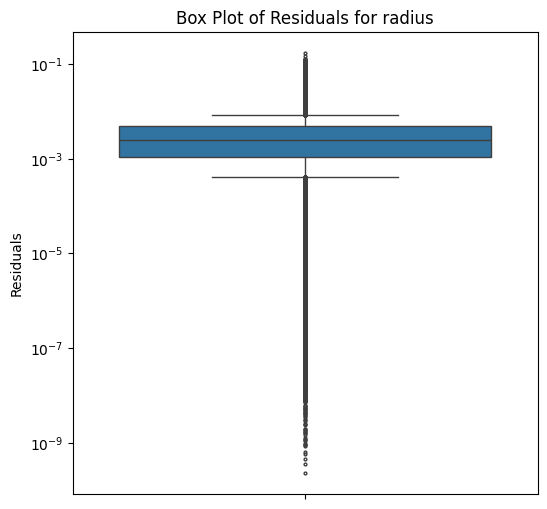

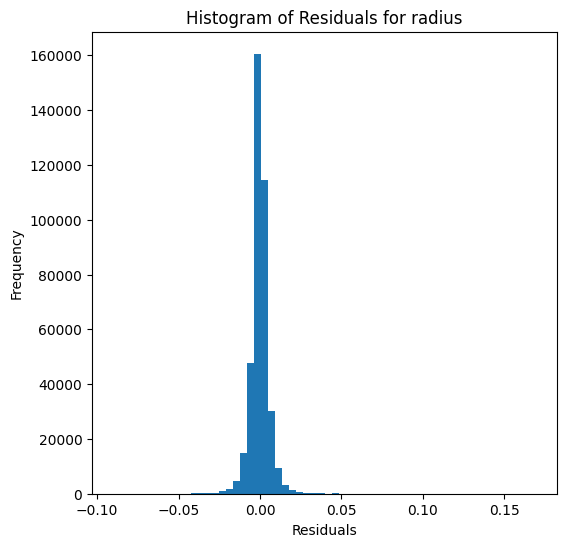

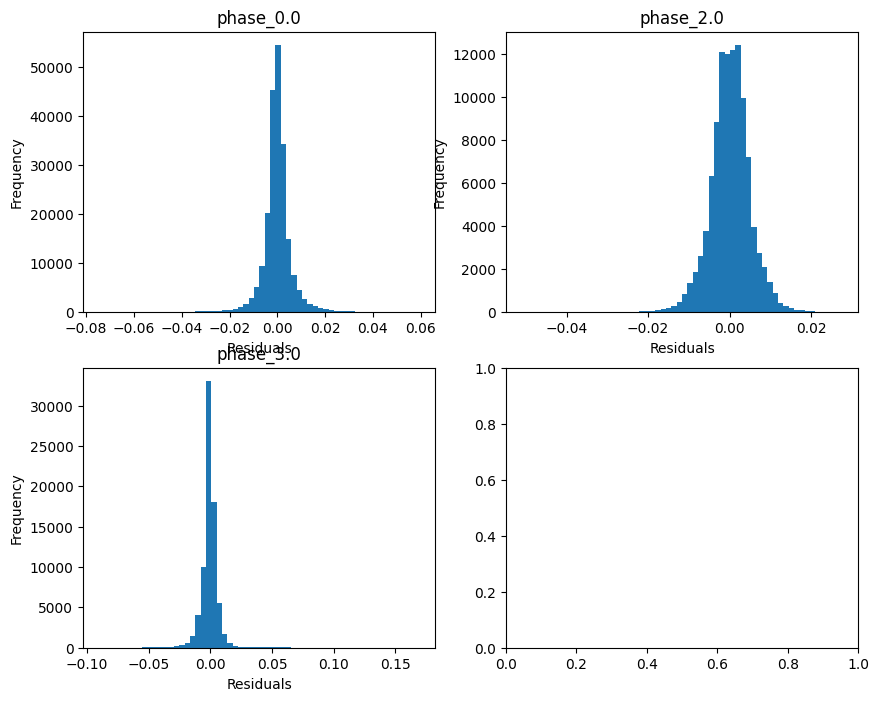

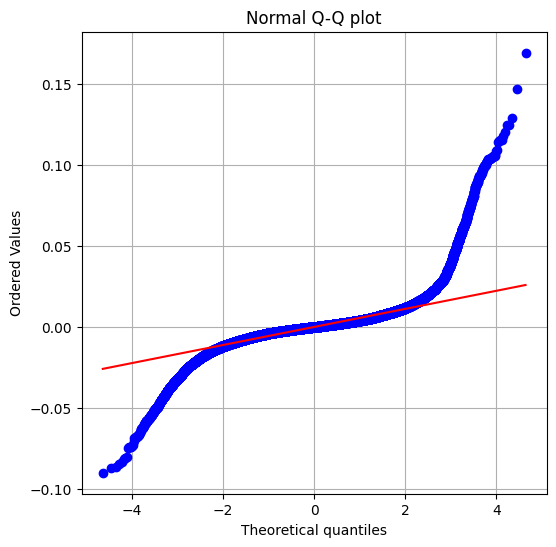

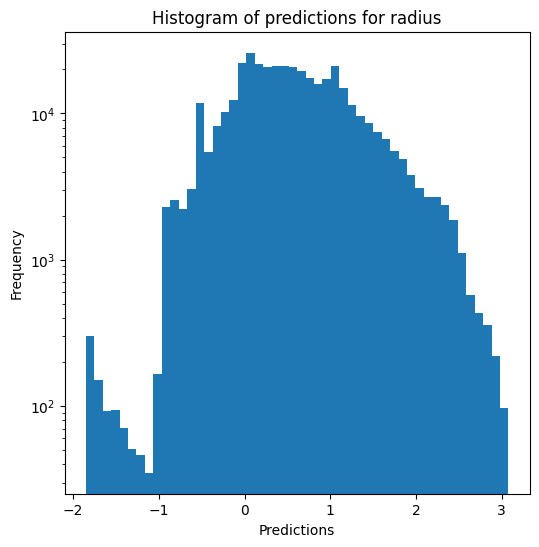

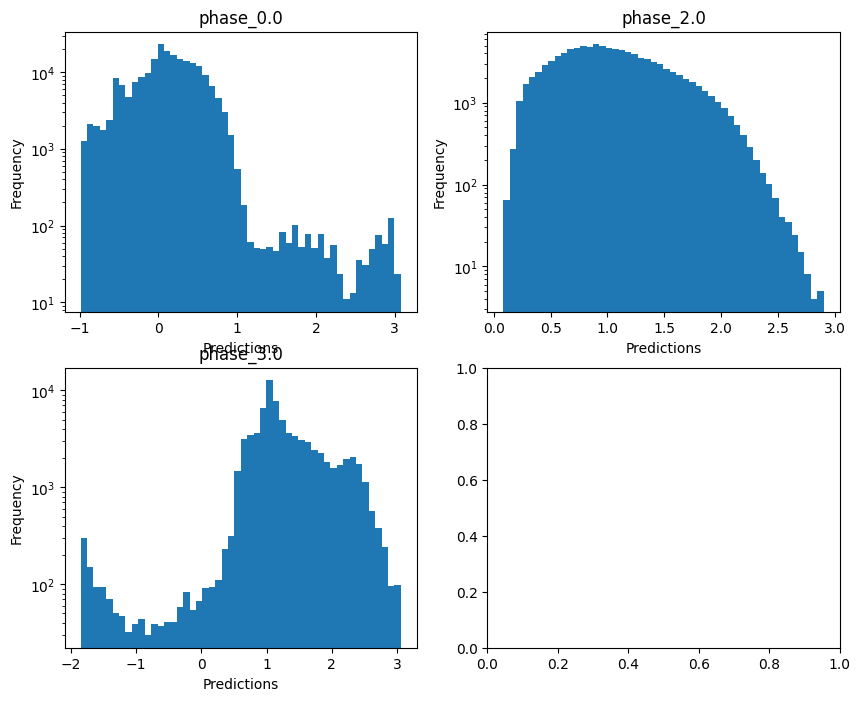

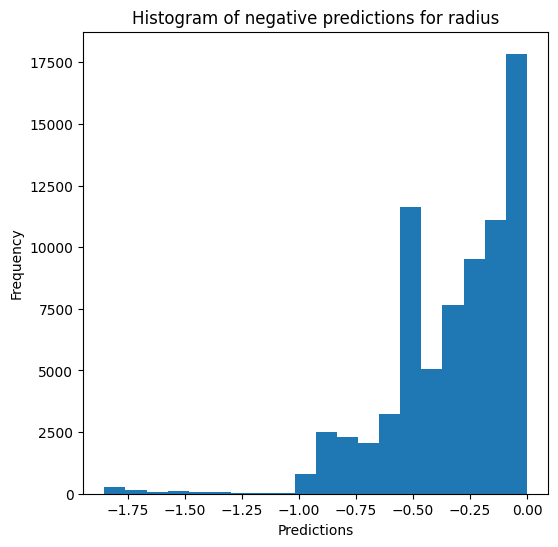

Saving predictions and results...


In [16]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### Random forests

In [17]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999272514194347
  RMSE :  0.0281557728235542
  MAE :  0.008851647808148724
  MedAE :  0.002466730917954685
  CORR :  0.9999636292504032
  MAX_ER :  1.9715440625856822
  Percentiles : 
    75th percentile :  0.007184259944556182
    90th percentile :  0.019639223339910354
    95th percentile :  0.03507842704873723
    99th percentile :  0.10437294120456574

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999748783427481
  RMSE :  0.016380694948155635
  MAE :  0.008364516305232947
  MedAE :  0.004331240334604747
  CORR :  0.999987578431358
  MAX_ER :  0.3876454793620763
  Percentiles : 
    75th percentile :  0.0100427454331804
    90th percentile :  0.01896115229591

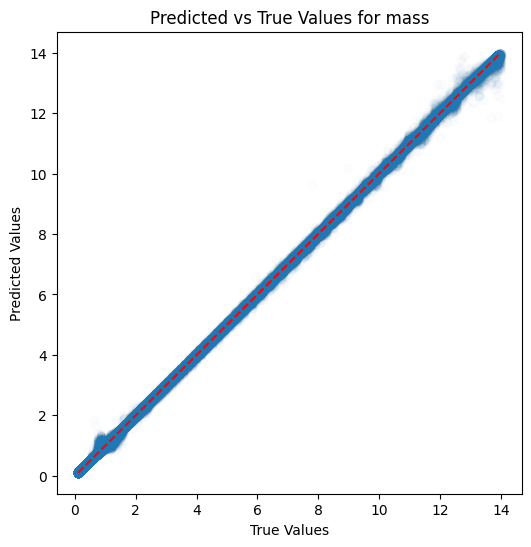

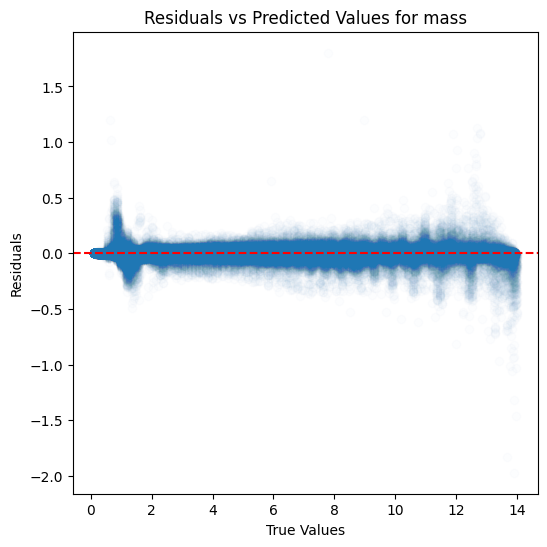

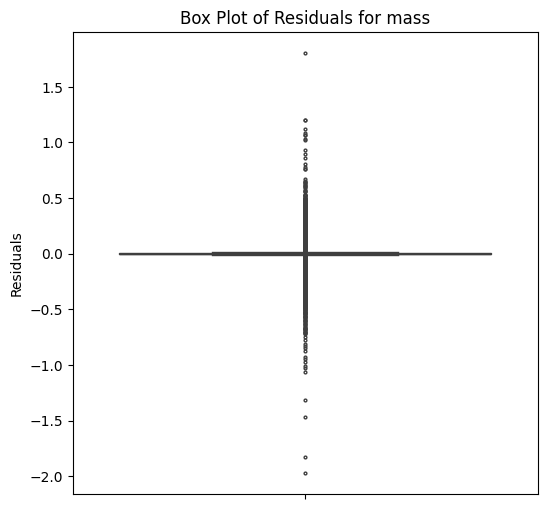

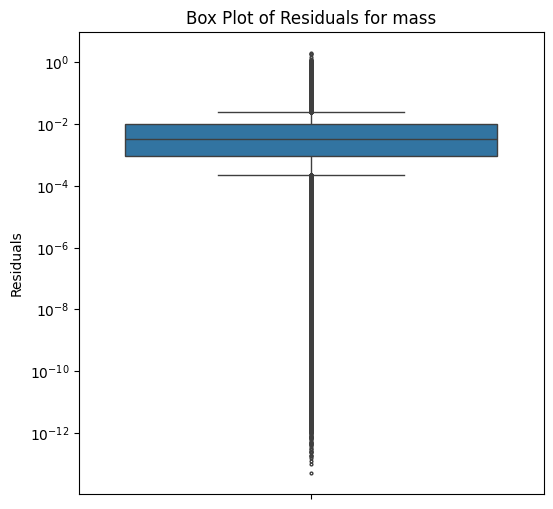

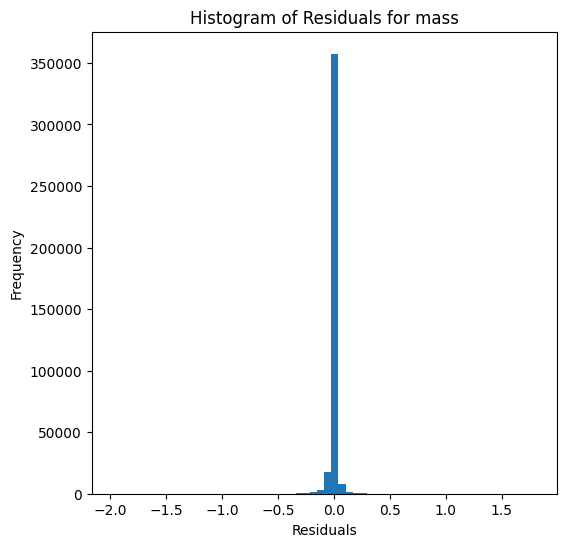

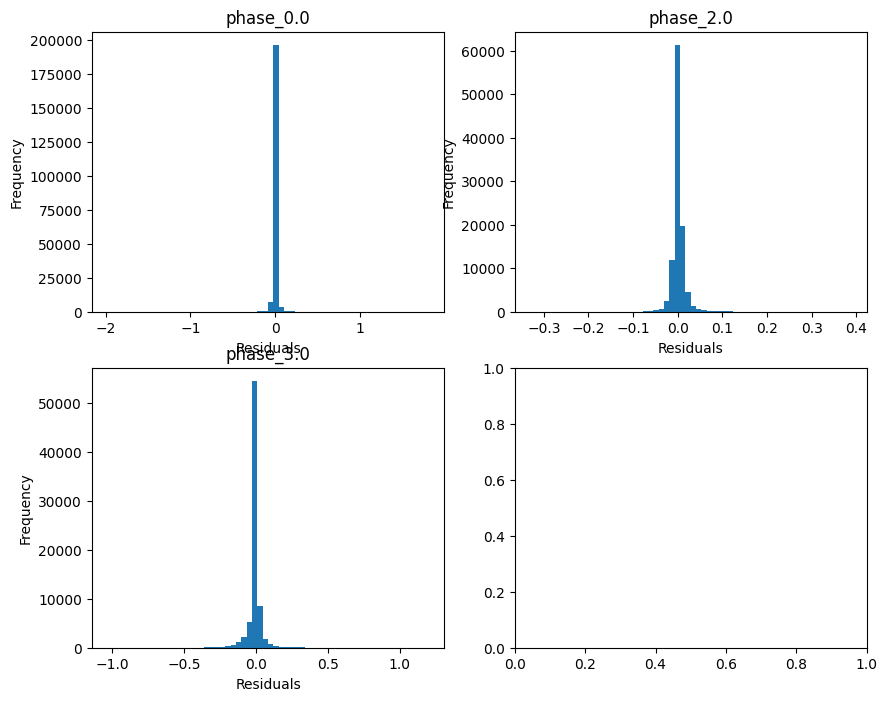

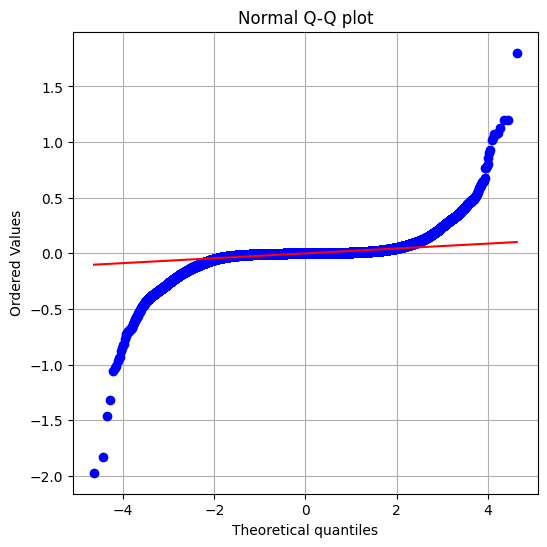

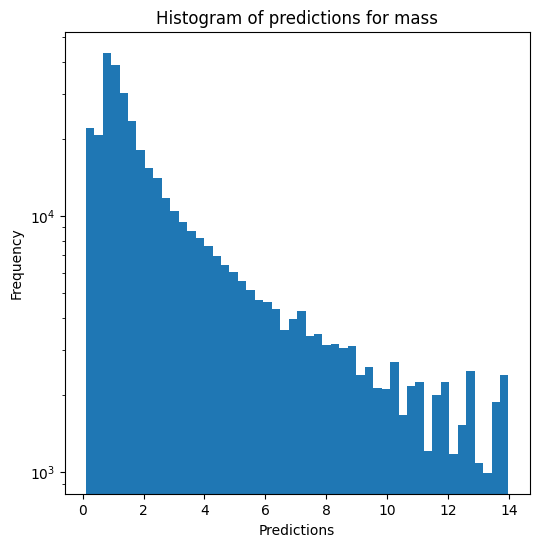

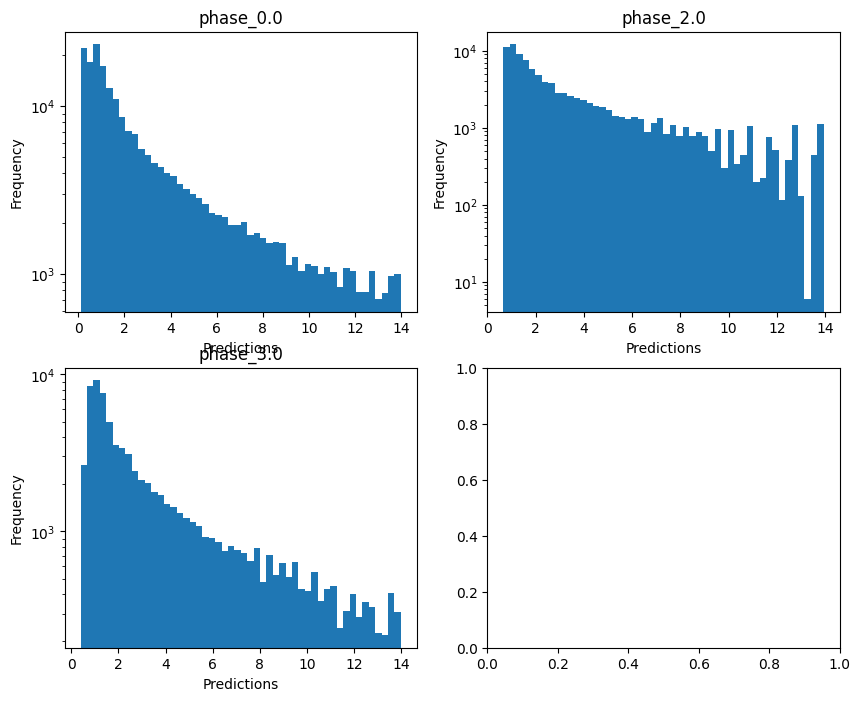


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.999954273279007
  RMSE :  0.002853961572747469
  MAE :  0.001634058112005501
  MedAE :  0.0009028285606417635
  CORR :  0.9999771484155251
  MAX_ER :  0.11315406053672605
  Percentiles : 
    75th percentile :  0.0019465909681308097
    90th percentile :  0.0038126351600116016
    95th percentile :  0.005664935006246774
    99th percentile :  0.011346668824440685

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.999915869819619
  RMSE :  0.004315554552690224
  MAE :  0.0029546148610459792
  MedAE :  0.002014089156679444
  CORR :  0.9999592448517991
  MAX_ER :  0.05590281114078155
  Percentiles : 
    75th percentile :  0.003990937189648047
    90th percentile :  0.006706135126372949
    95th percentile :  0.008826326715567942
    99th percentile :  0.01468024412420942

radius results f

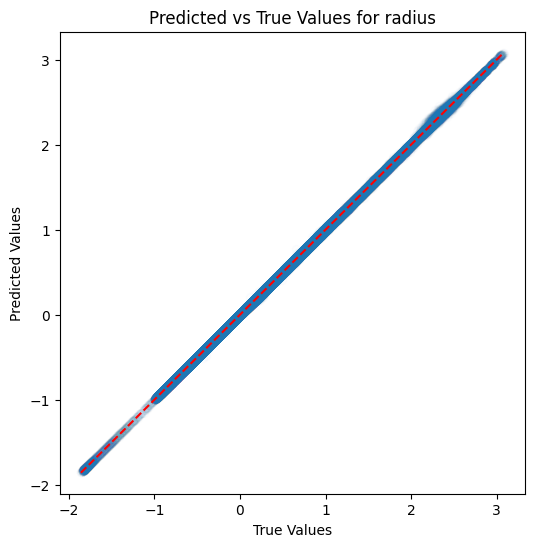

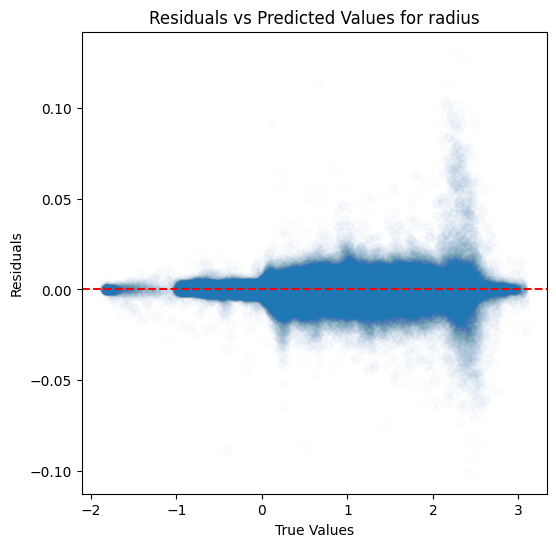

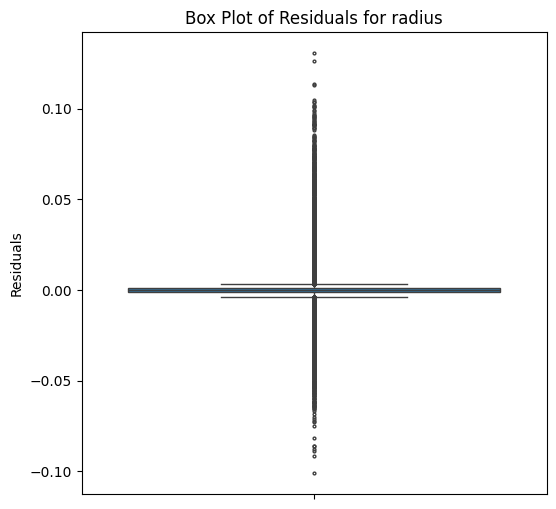

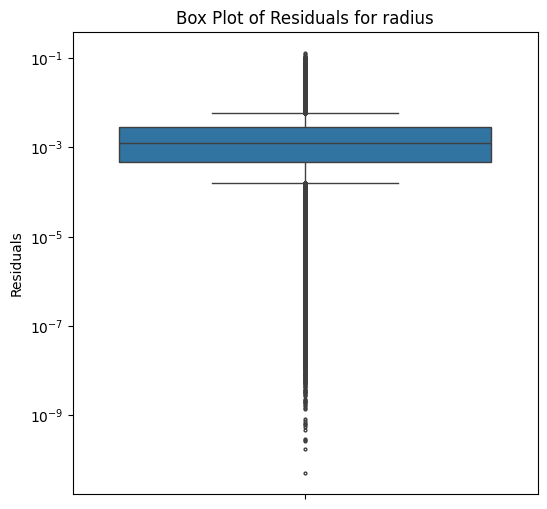

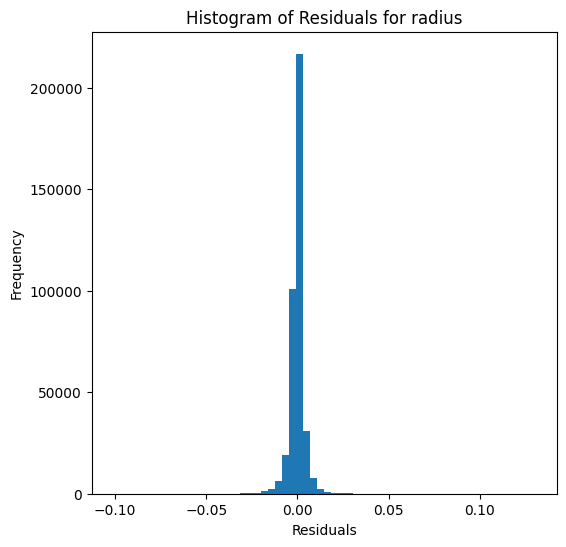

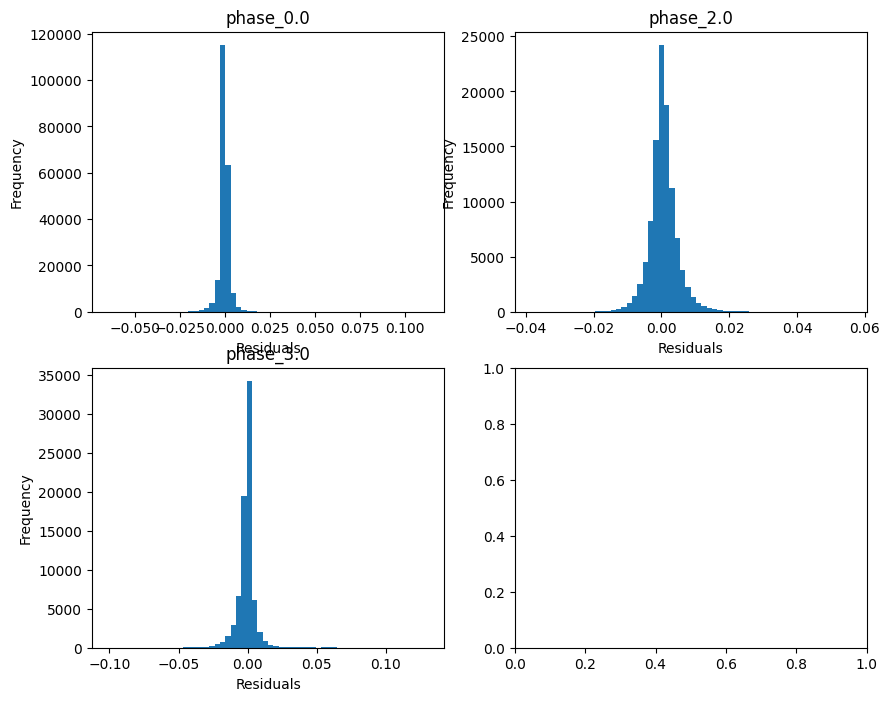

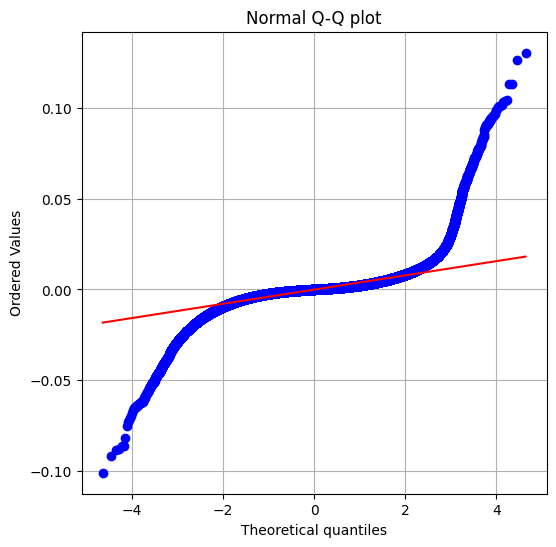

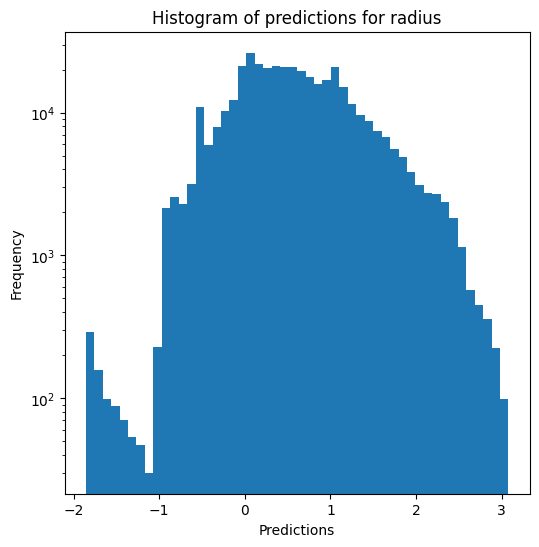

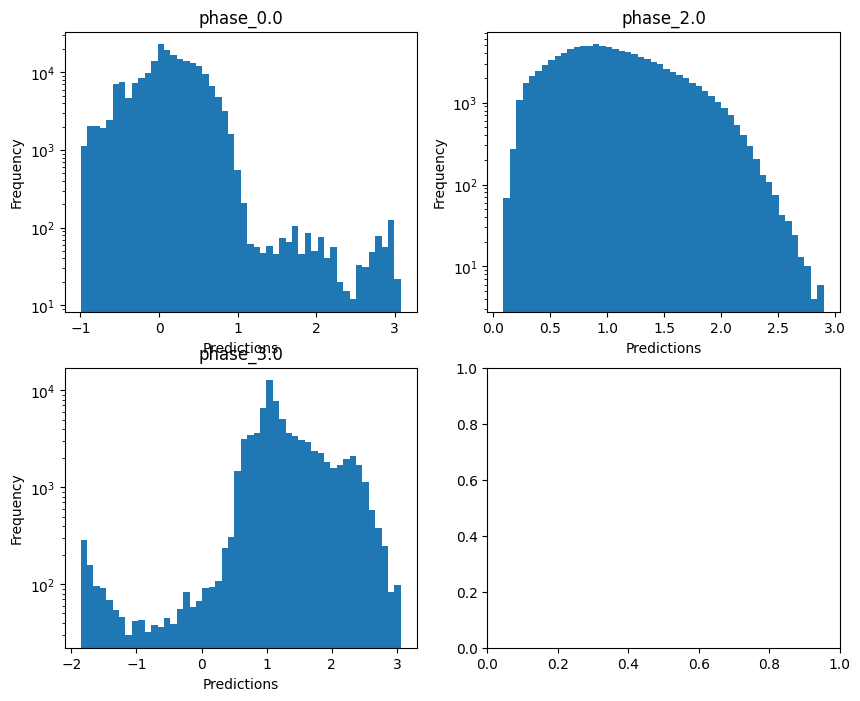

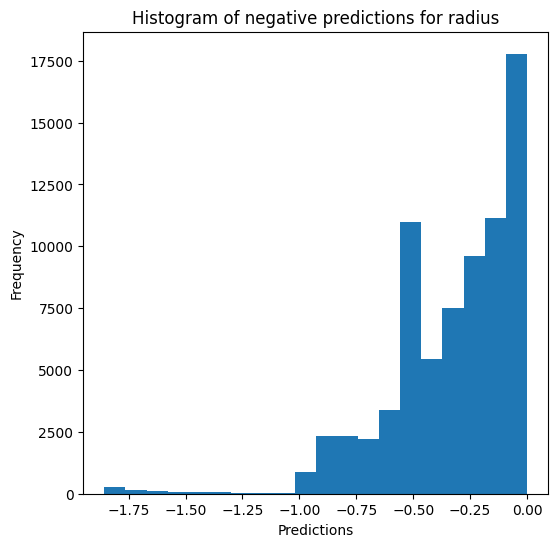

Saving predictions and results...


In [18]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True, n_jobs=5)

### XGBoost

In [19]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9988060825951395
  RMSE :  0.1140586552050052
  MAE :  0.06421166827237894
  MedAE :  0.032417196436711926
  CORR :  0.9994029428086492
  MAX_ER :  2.302518392782492
  Percentiles : 
    75th percentile :  0.07760916357107261
    90th percentile :  0.15630014146359042
    95th percentile :  0.22952538828885494
    99th percentile :  0.4486116173348846

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997590049106206
  RMSE :  0.052322327024145285
  MAE :  0.03612506183253485
  MedAE :  0.02403747932798972
  CORR :  0.9998847737638235
  MAX_ER :  0.5749695953718383
  Percentiles : 
    75th percentile :  0.04892103581129437
    90th percentile :  0.08319237051435771
    95th percentile 

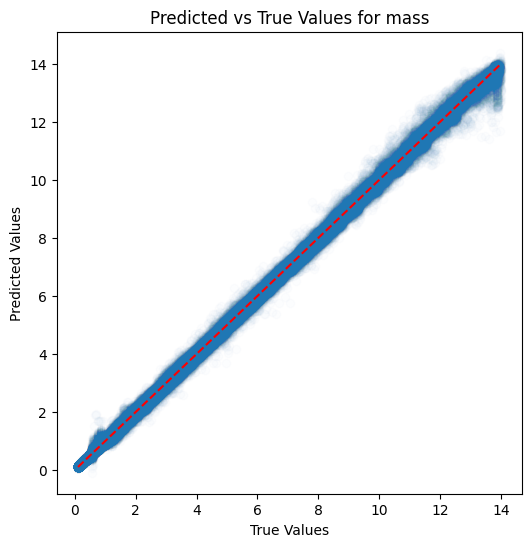

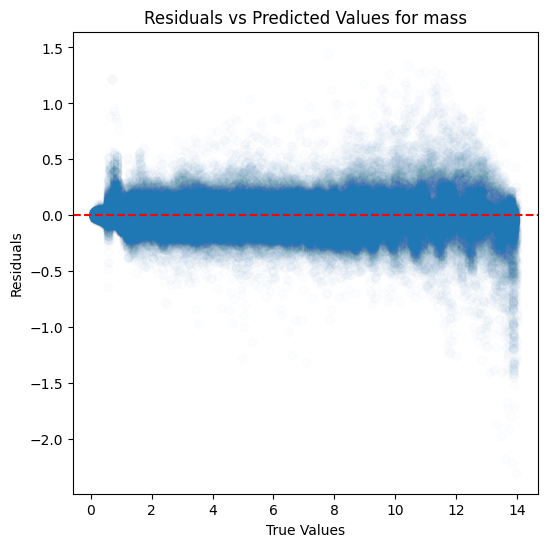

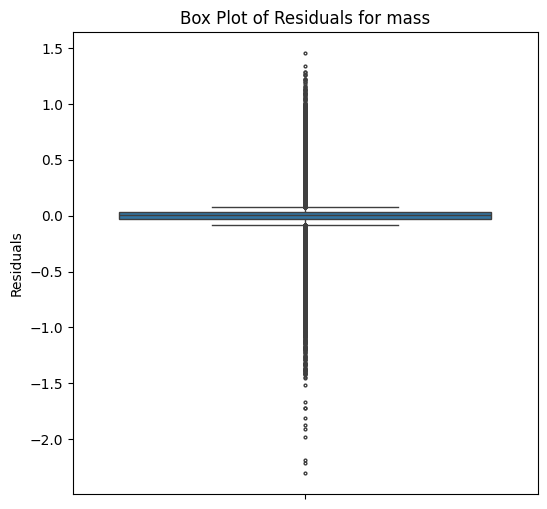

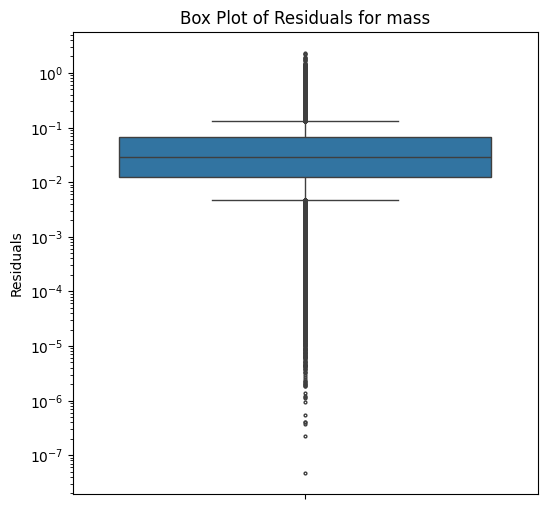

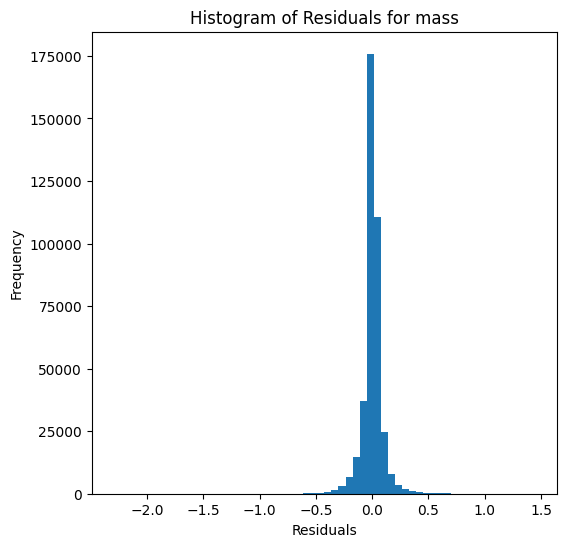

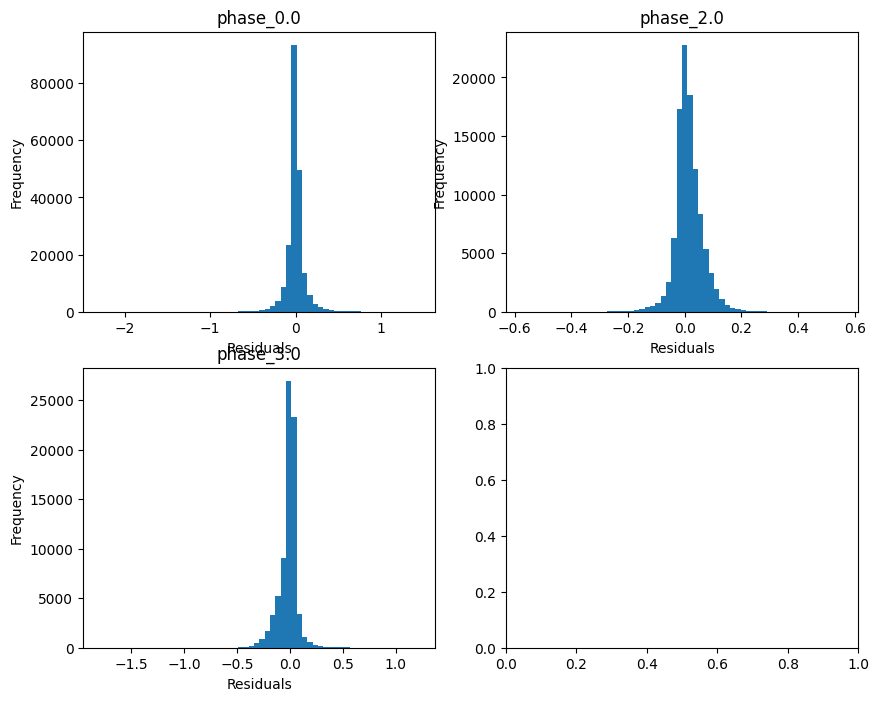

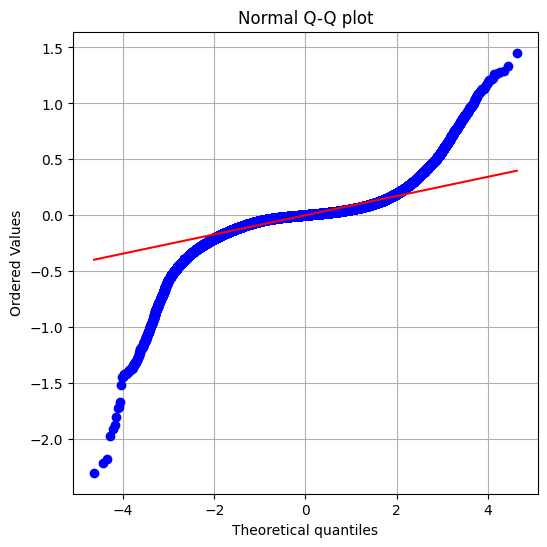

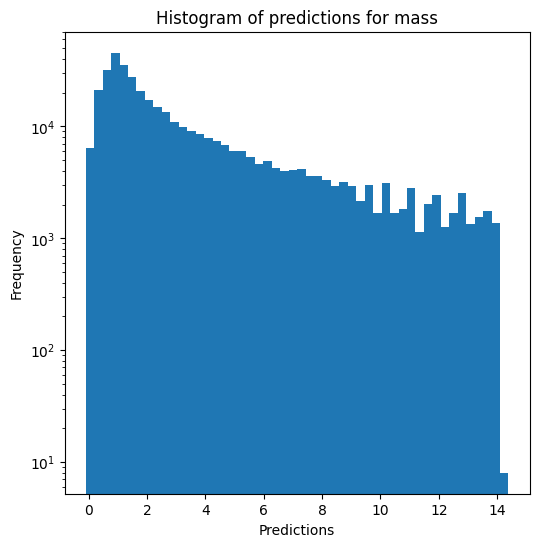

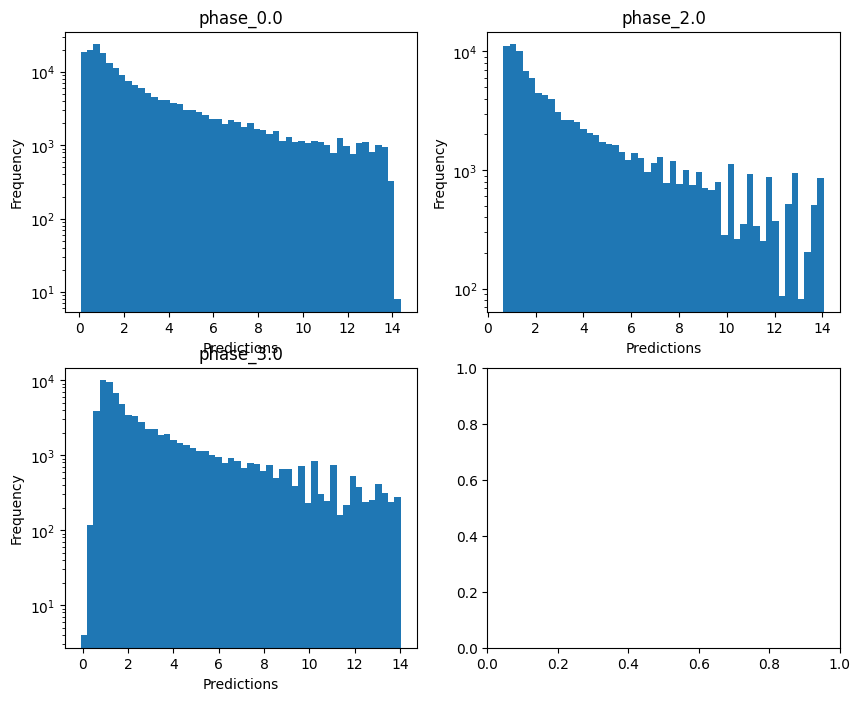

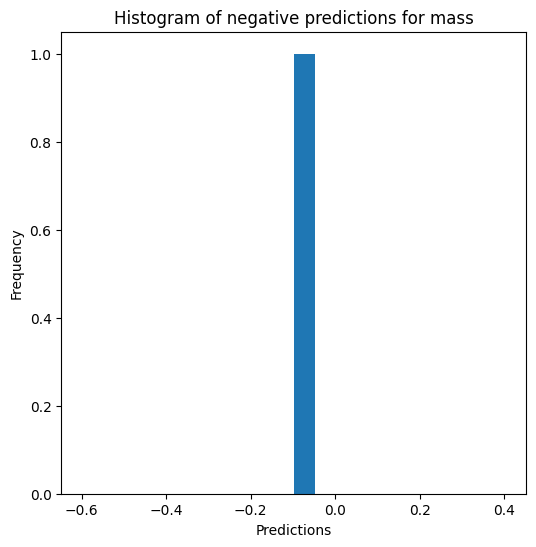


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9995316778942331
  RMSE :  0.009122362321712117
  MAE :  0.006968426619692465
  MedAE :  0.00549809834231528
  CORR :  0.9997658125307401
  MAX_ER :  0.06950863651605355
  Percentiles : 
    75th percentile :  0.009764735225205965
    90th percentile :  0.014895004595915654
    95th percentile :  0.01863699745801645
    99th percentile :  0.026720597341744926

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9994170466959919
  RMSE :  0.011283144985862152
  MAE :  0.008769671104498708
  MedAE :  0.007121132467737323
  CORR :  0.9997088032289221
  MAX_ER :  0.0678817394138389
  Percentiles : 
    75th percentile :  0.012422692839197946
    90th percentile :  0.01842199201088211
    95th percentile :  0.022595136037801916
    99th percentile :  0.03161122351957961

radius results for the

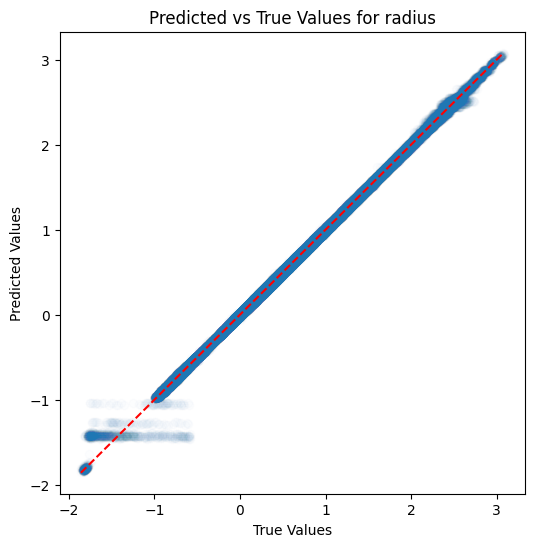

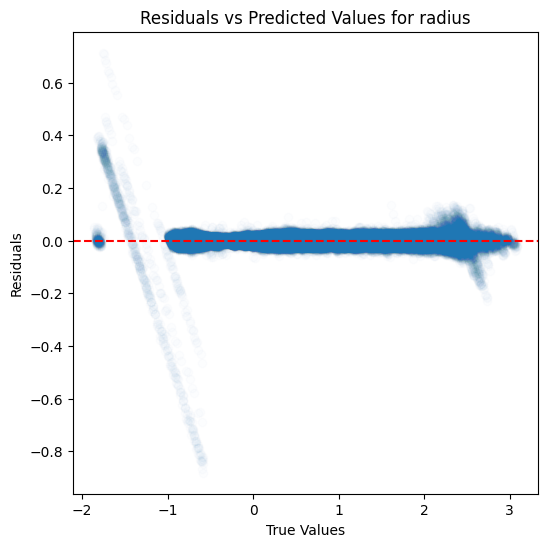

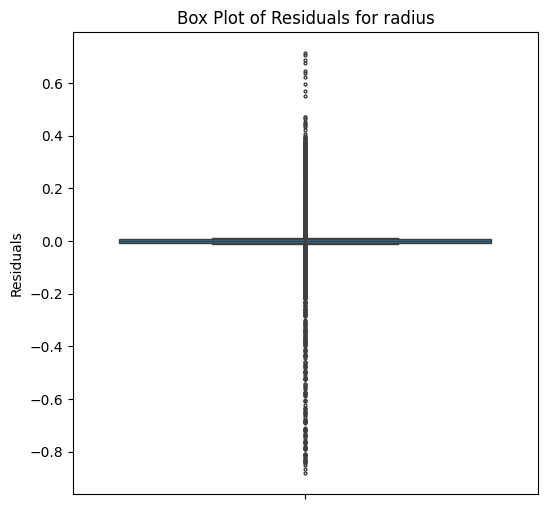

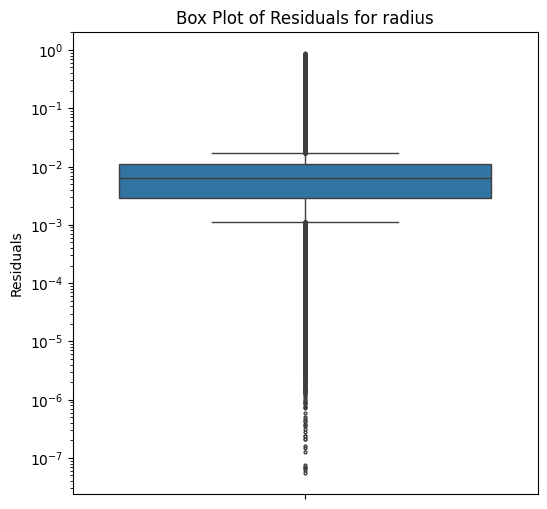

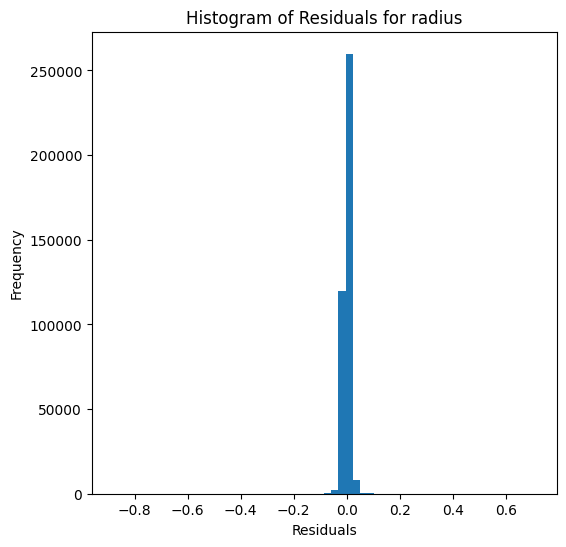

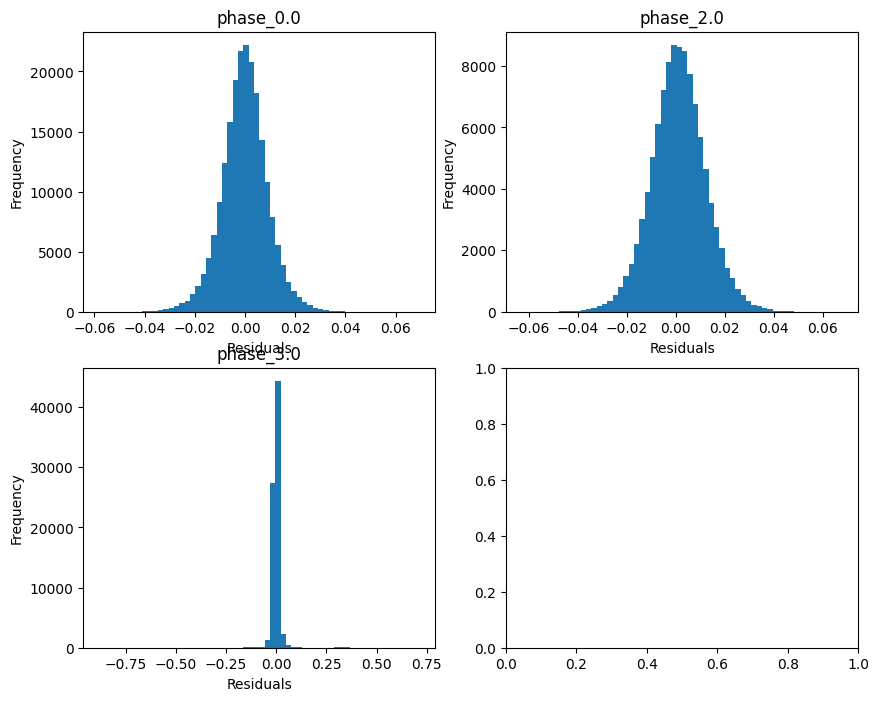

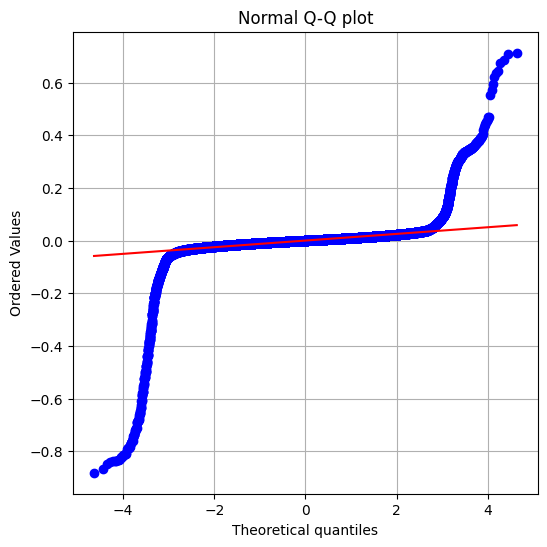

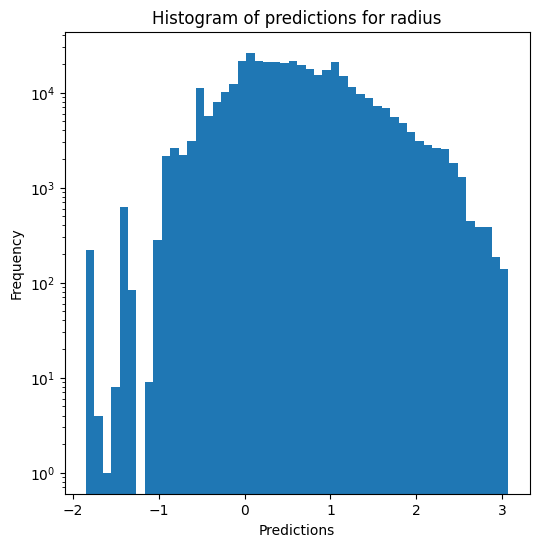

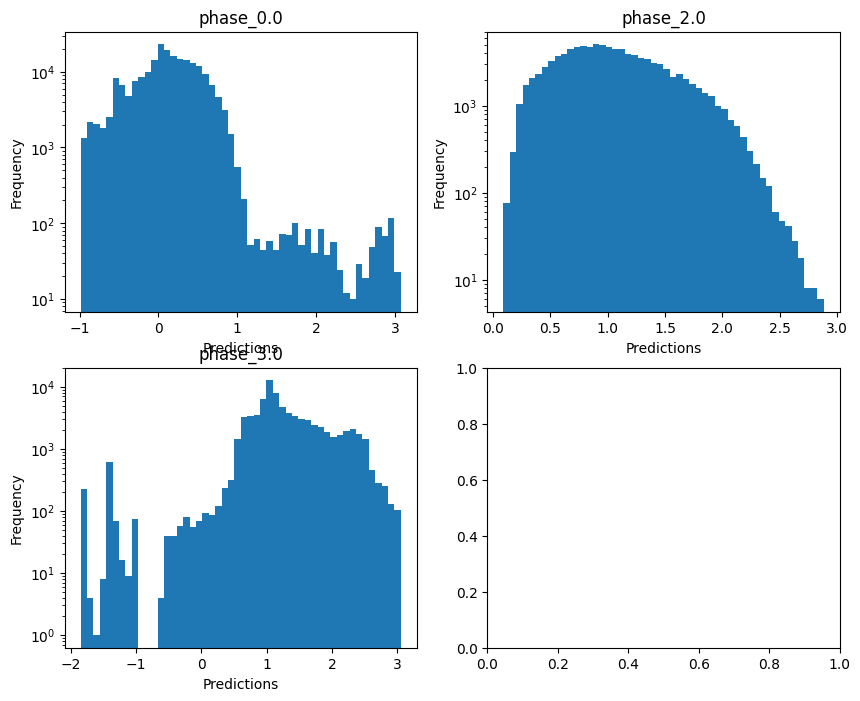

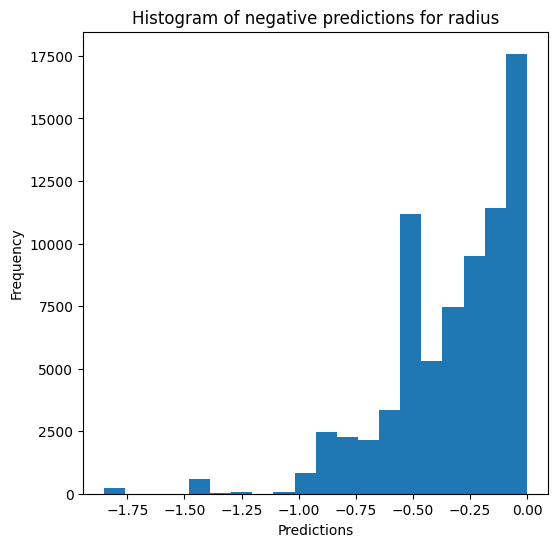

Saving predictions and results...


In [20]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True, n_jobs=5)

### Multi-layer perceptron

In [21]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_14 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.006806018276720341
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.006915490278346925
3 

...

0.00629347343944396
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.006844440982985866
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.00651800249087681

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9962005204185861
  RMSE :  0.20508645874586898
  MAE :  0.10801455864156208
  MedAE :  0.05104043969616057
  CORR :  0.9981009515325953
  MAX_ER :  3.8791764112049805
  Percentiles : 
    75th percentile :  0.12904863995441052
    90th percentile :  0.2742928847336161
    95th percentile :  0.3841267002078582
    99th percentile :  0.6912092325159281

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.996214834842145
  RMSE :  0.22698643493170936
  MAE :  0.15942483952793438
  MedAE :  0.11114159758060715
  CORR :  0.9981658283323158
  MAX_ER :  2.6315811224630377
  Percentiles : 
    75th percentile :  0.2019696434856071
    90th percentile :  0.36172674252118536
    95th percentile :  0.4924747041007479
    99th percentile :  0.726177542171767

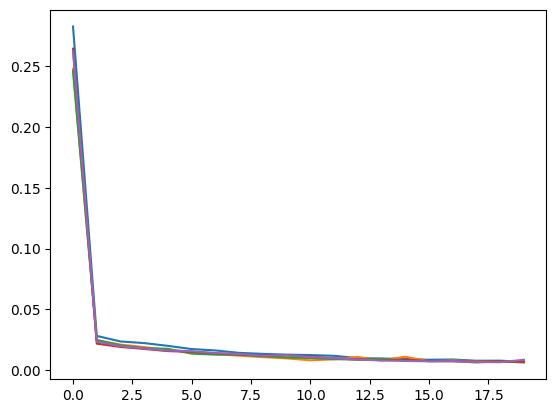

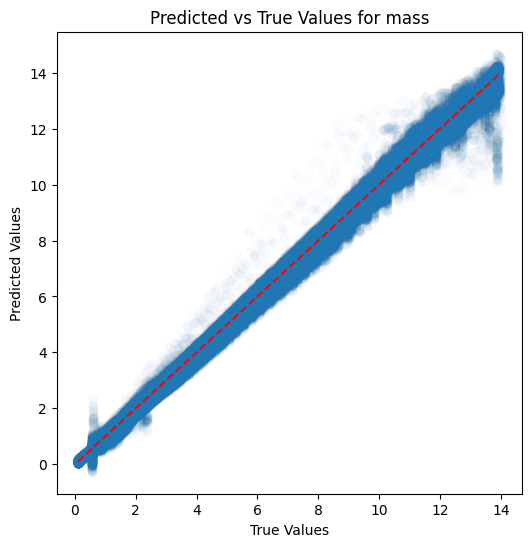

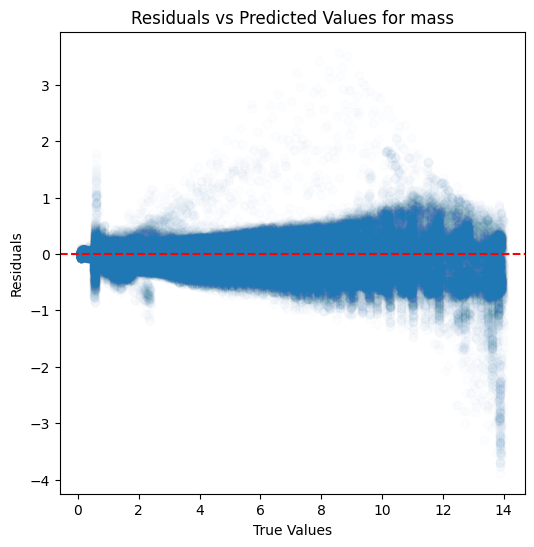

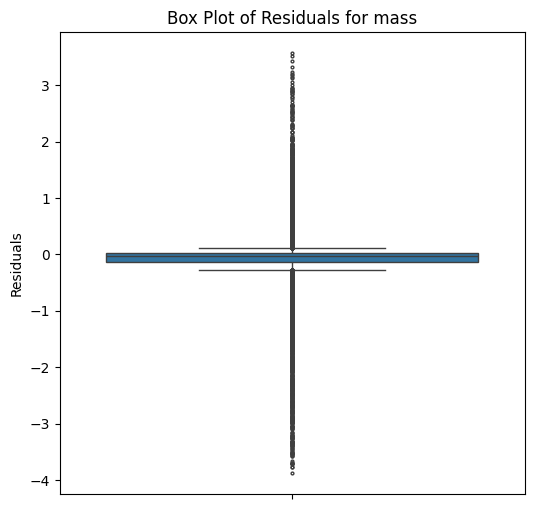

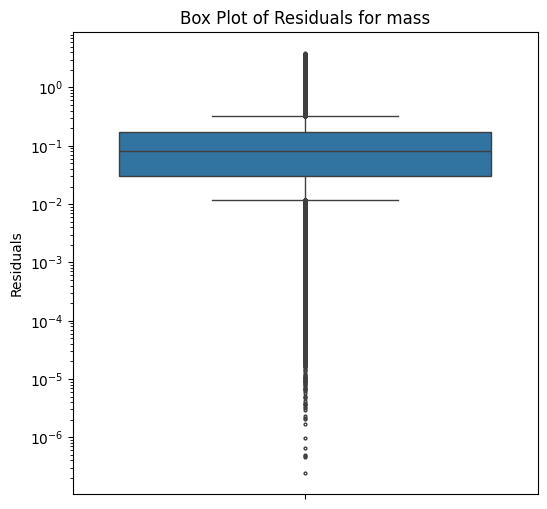

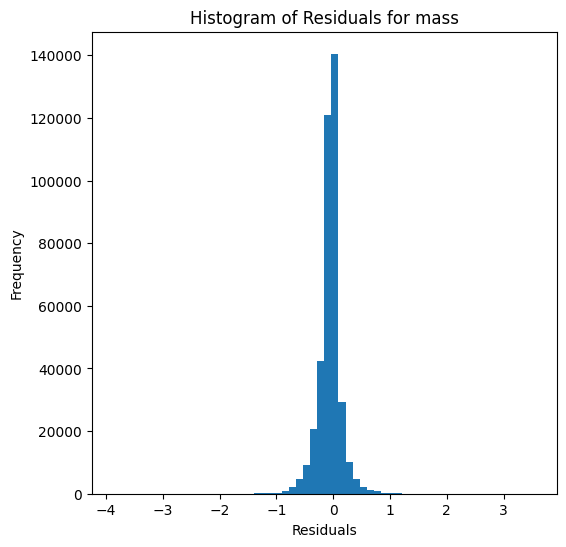

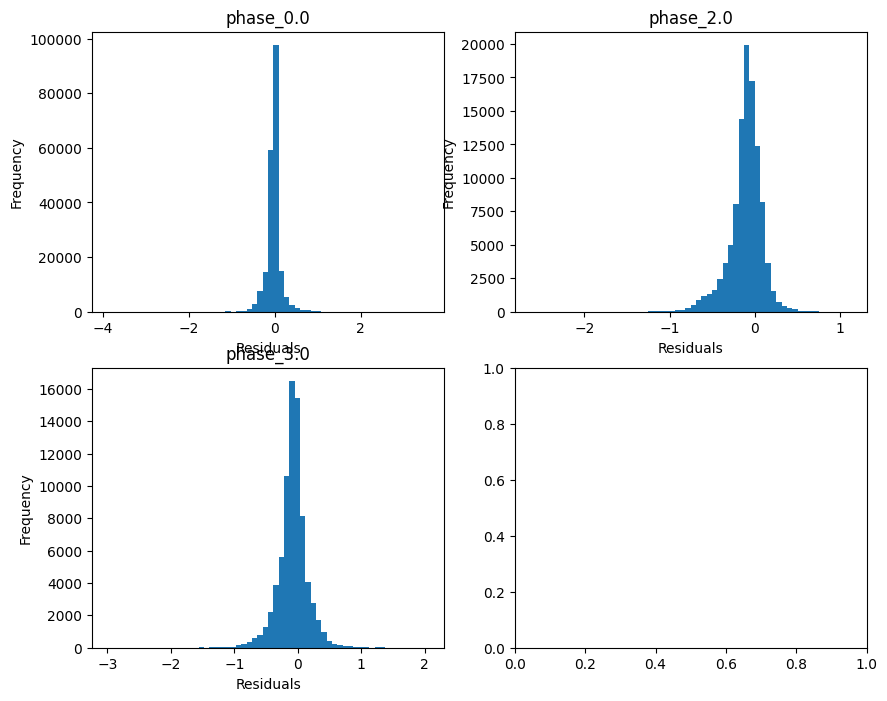

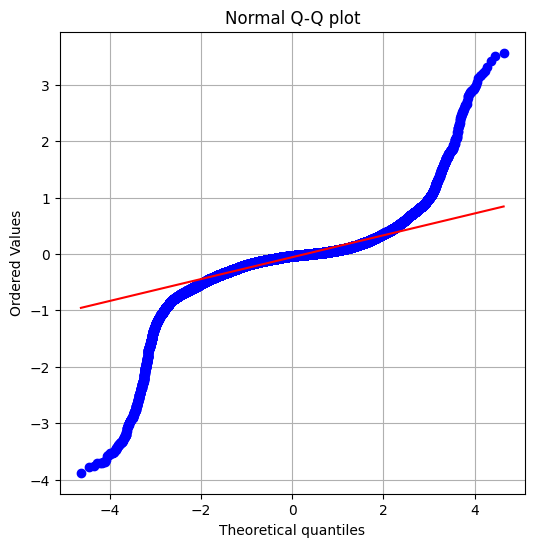

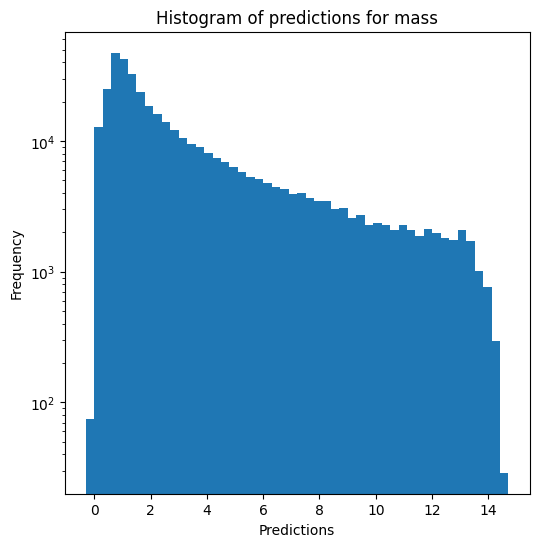

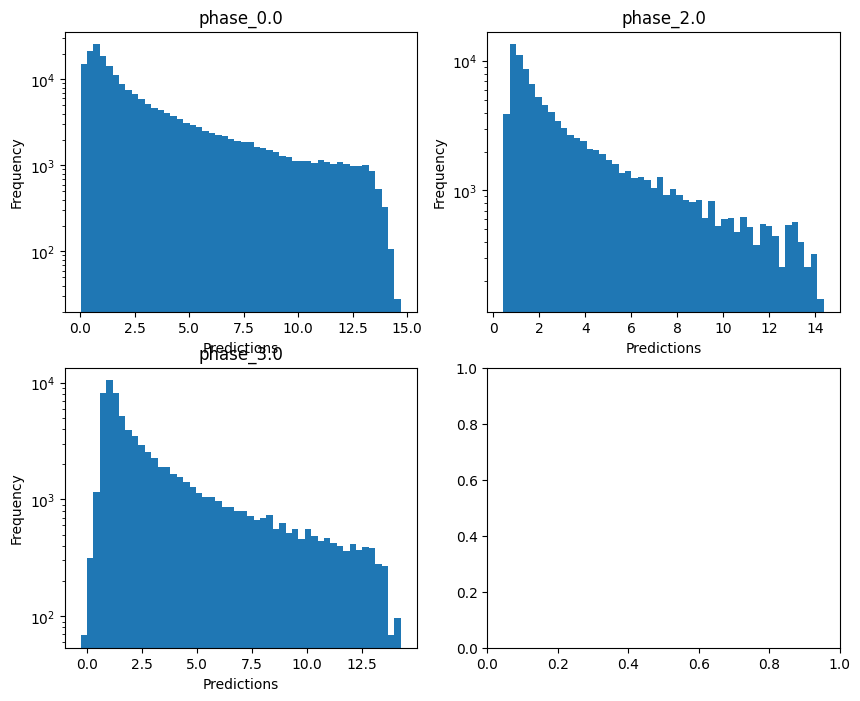

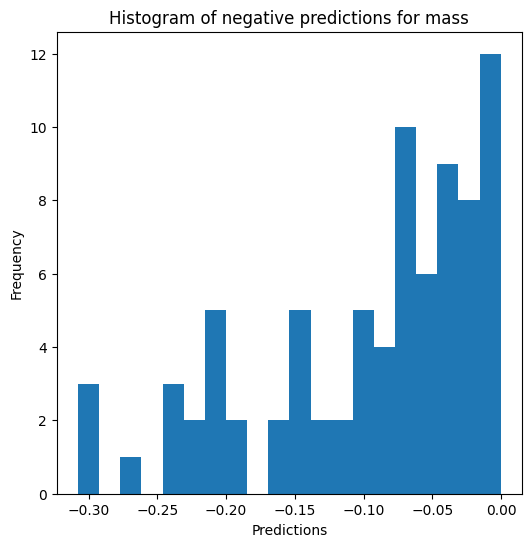


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9977087320299743
  RMSE :  0.0206816775867941
  MAE :  0.01582301028435908
  MedAE :  0.01258163075997879
  CORR :  0.9988657455811601
  MAX_ER :  0.12968385135237925
  Percentiles : 
    75th percentile :  0.022198550406842366
    90th percentile :  0.033209546267919714
    95th percentile :  0.04217064801344021
    99th percentile :  0.06089759093801548

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9972125568463757
  RMSE :  0.027633845101238834
  MAE :  0.020513073464717875
  MedAE :  0.015041218647519727
  CORR :  0.998607588204276
  MAX_ER :  0.0963852762935562
  Percentiles : 
    75th percentile :  0.027903145220633307
    90th percentile :  0.048769422246543244
    95th percentile :  0.06141552104206804
    99th percentile :  0.07956476933119609

radius results for the phas

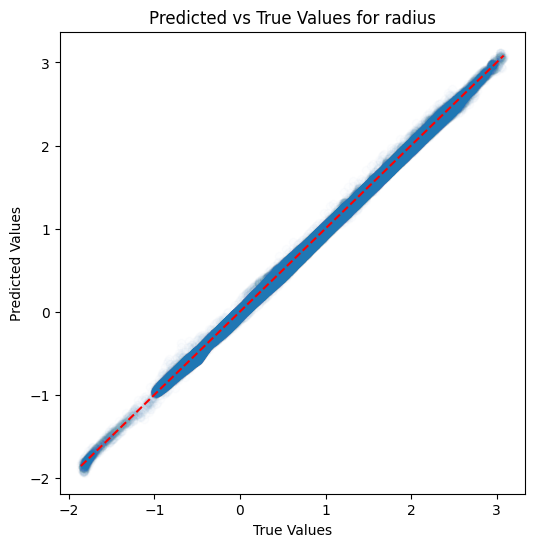

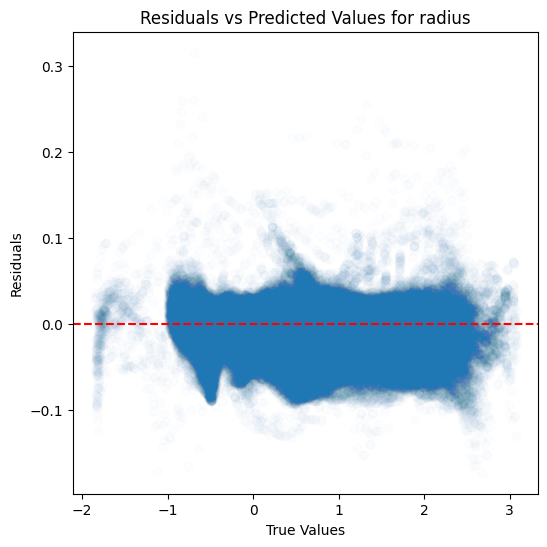

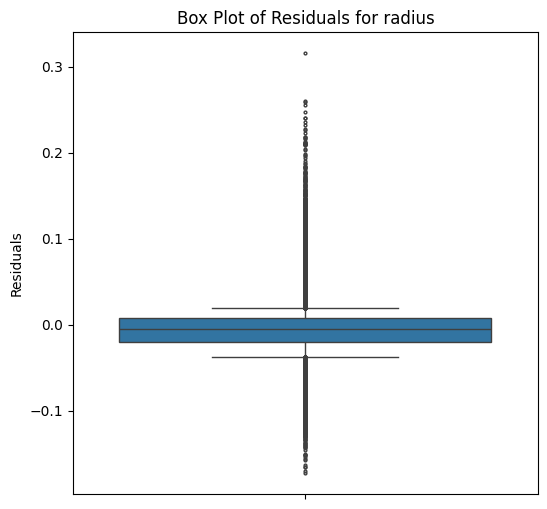

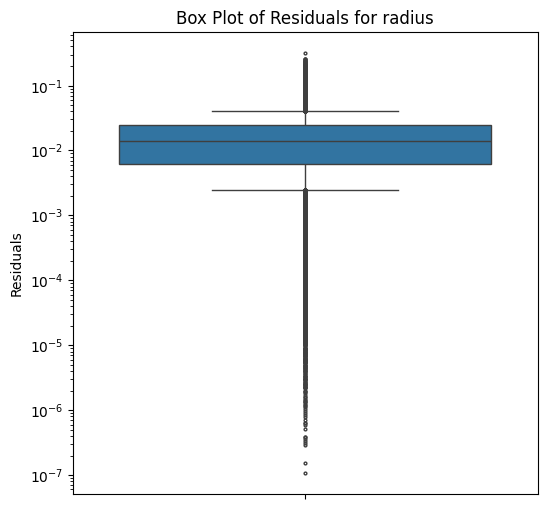

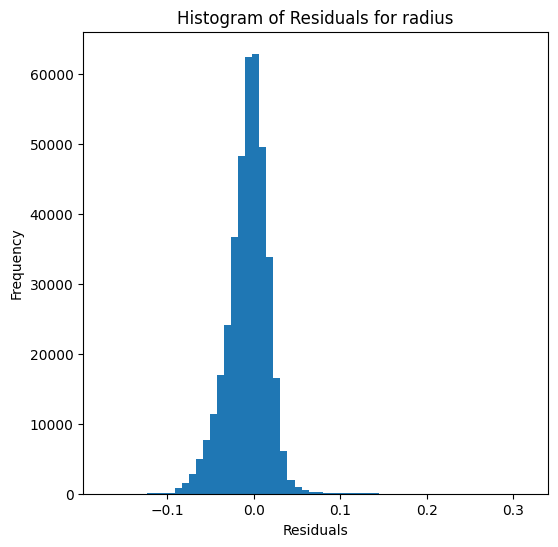

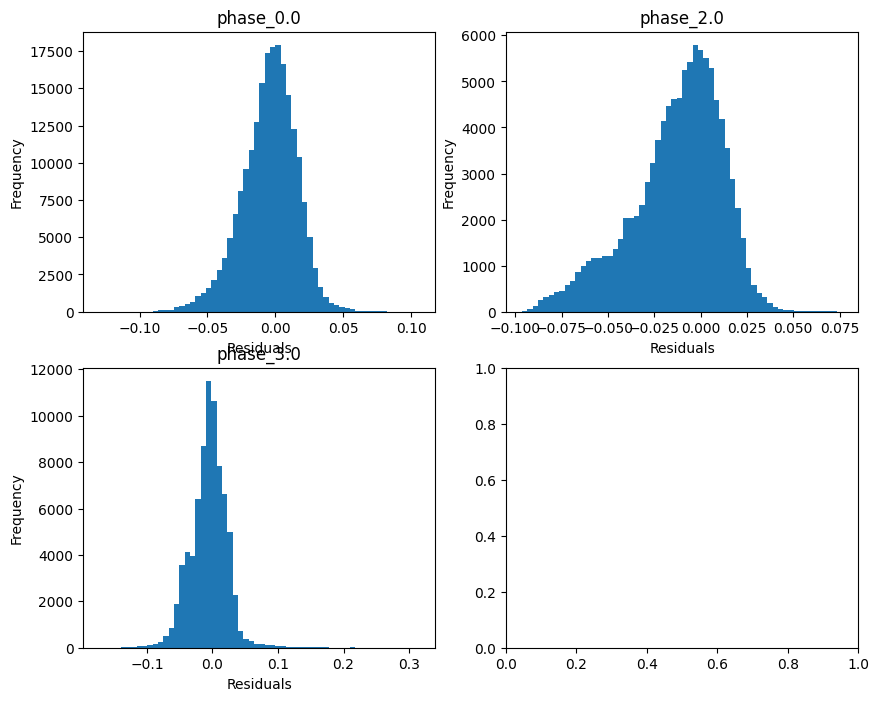

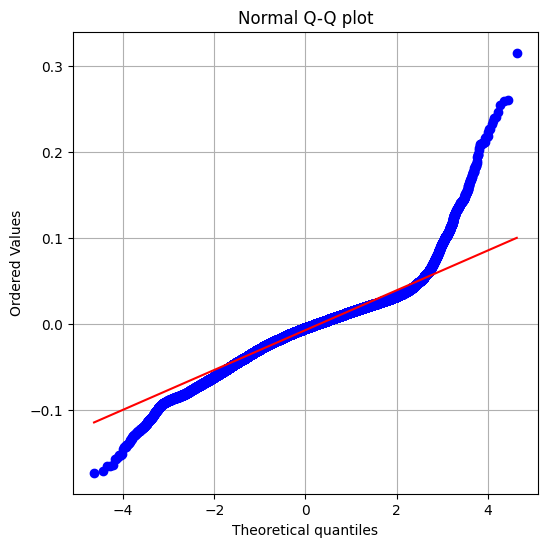

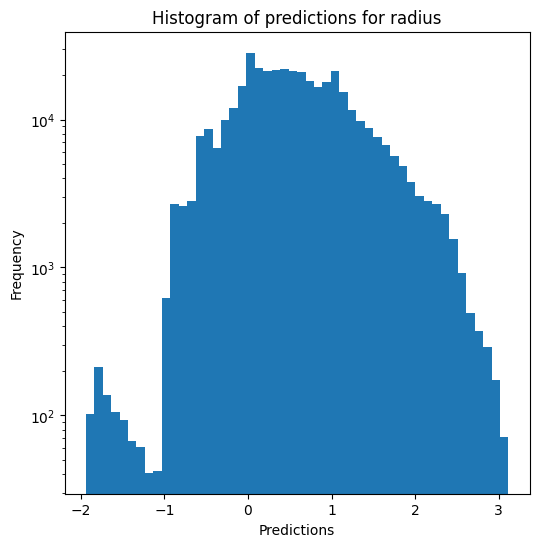

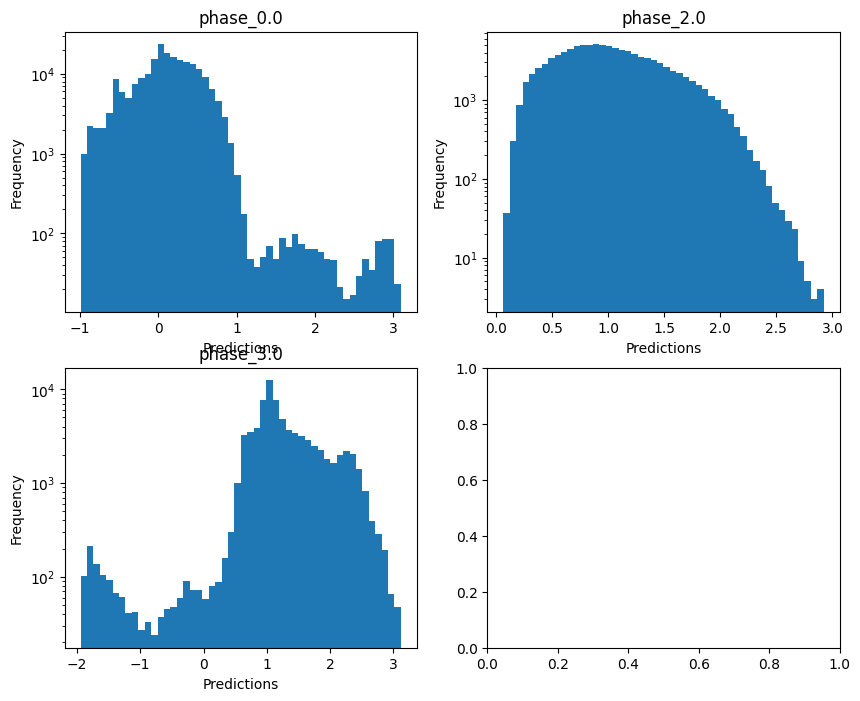

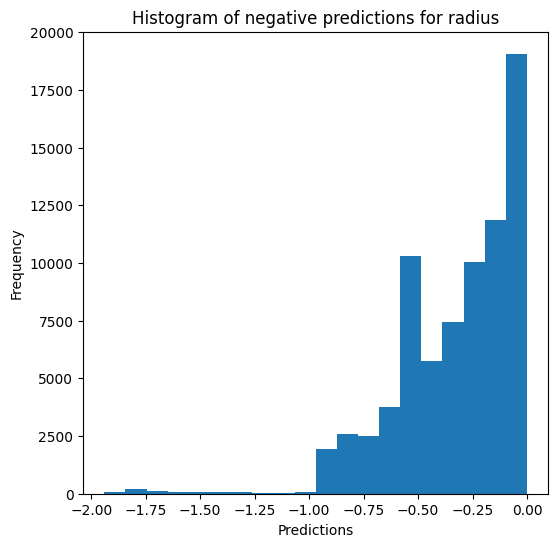

Saving predictions and results...


In [22]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=True, use_preds=False, save=True, show=True, 
                                     hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)